# Compare Imagery Spectra to Ground Truth: Rounds 1 and 2

This notebook extracts station-level spectra from the May 4 and May 18, 2026 MicaSense imagery for:

- **Westham Center** stations beginning with `W`;
- **Brunswick** stations beginning with `B`;
- Round 1 and Round 2;
- 2 × 2 m quadrats only;
- field-spectrometer sample type `R`.

## Calibration chains

All final values are placed in the corrected Westham Center May 18 reference.

### Round 2 — May 18

- Westham:
  - raw Westham May 18
  - final Westham May 18 correction
- Brunswick:
  - raw Brunswick May 18
  - Brunswick May 18 → Westham May 18 scope
  - final Westham May 18 correction

### Round 1 — May 4

- Westham:
  - raw Westham May 4
  - Westham May 4 → Westham May 18 scope
  - final Westham May 18 correction
- Brunswick:
  - raw Brunswick May 4
  - Brunswick May 4 → Westham May 4 scope
  - Westham May 4 → Westham May 18 scope
  - final Westham May 18 correction

Source band 5 is PAN and is excluded from all spectral analyses.

> No SAS URL or token is stored in this notebook.

## 1. Imports and setup

In [1]:
from pathlib import Path
import os
import sys

import geopandas as gpd
import numpy as np
import pandas as pd
import rasterio
from IPython.display import display
from matplotlib import pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from rasterio.mask import mask
from rasterio.transform import rowcol
from rasterio.windows import Window
import seaborn as sns
from shapely.geometry import box, mapping
from sklearn.metrics import r2_score

import hatfield_funcs as hf

project_root = Path("../..").resolve()
sys.path.insert(0, str(project_root / "src"))

from biofilm_spectra.processing.micasense import *
from biofilm_spectra.processing.spectral_matrix import to_spectral_matrix
from my_extra_to_hatfield_funcs.io_funcs import *

plt.style.use("default")
%config InlineBackend.figure_format = "retina"

pd.set_option("display.max_columns", 120)

## 2. Azure configuration

In [2]:
STORAGE_ACCOUNT_NAME = "geoanalytics"
CONTAINER_NAME = "wesa-fup-restricted-027817p"

if os.getenv("GA_STORAGE_ACCOUNT_NAME") is None:
    raise EnvironmentError(
        "This notebook is configured for GeoAnalytics. "
        "GA_STORAGE_ACCOUNT_NAME is not set."
    )

hf.config.configure_azure()
hf.config.configure_data_root_path(CONTAINER_NAME)

os.environ.setdefault("AZURE_STORAGE_ACCOUNT", STORAGE_ACCOUNT_NAME)
os.environ.setdefault("GDAL_AZURE_USE_MSI", "YES")
os.environ.setdefault("GDAL_CACHEMAX", "512")

sas_token = os.getenv("AZURE_STORAGE_SAS_TOKEN")
if sas_token:
    os.environ["AZURE_STORAGE_SAS_TOKEN"] = sas_token

print("Storage account:", STORAGE_ACCOUNT_NAME)
print("Container:", CONTAINER_NAME)
print("External SAS token available:", bool(sas_token))

Storage account: geoanalytics
Container: wesa-fup-restricted-027817p
External SAS token available: False


## 3. Analysis parameters

In [3]:
ROUNDS_OF_INTEREST = [1, 2]
SAMPLE_TYPE_OF_INTEREST = "R"
USE_3X3M_QUADRATS = False
MIN_IMAGERY_COVERAGE = 0.999
ALL_TOUCHED = False

CORRECT_IMAGERY_CRS = "EPSG:6339"

SOURCE_BANDS_11B_TO_10B = [1, 2, 3, 4, 6, 7, 8, 9, 10, 11]
SOURCE_BANDS_10B = list(range(1, 11))

WAVELENGTHS_NM = [int(v) for v in MICASENSE_10B_CENTER_WAVELENGTHS]
BAND_NAMES = [f"B{i}" for i in range(1, 11)]

if len(WAVELENGTHS_NM) != 10:
    raise ValueError("Expected 10 MicaSense center wavelengths.")

ROUND_DATES = {
    1: "2026-05-04",
    2: "2026-05-18",
}

SITE_CONFIG = {
    "westham": {
        "label": "Westham Center",
        "station_prefix": "W",
    },
    "brunswick": {
        "label": "Brunswick",
        "station_prefix": "B",
    },
}

SITE_COLORS = {
    "westham": "#56E00A",
    "brunswick": "#0455FE",
}

STAGE_COLORS = {
    "uncorrected": "#4C78A8",
    "westham_may4_scope": "#72B7B2",
    "westham_may18_scope": "#B279A2",
    "fully_corrected": "#E45756",
}

STAGE_LABELS = {
    "uncorrected": "Uncorrected",
    "westham_may4_scope": "Westham May 4 scope",
    "westham_may18_scope": "Westham May 18 scope",
    "fully_corrected": "Fully corrected",
}

STAGE_MARKERS = {
    "uncorrected": "o",
    "westham_may4_scope": "v",
    "westham_may18_scope": "^",
    "fully_corrected": "D",
}

STAGE_ORDER_BY_ROUND_SITE = {
    (1, "westham"): [
        "uncorrected",
        "westham_may18_scope",
        "fully_corrected",
    ],
    (1, "brunswick"): [
        "uncorrected",
        "westham_may4_scope",
        "westham_may18_scope",
        "fully_corrected",
    ],
    (2, "westham"): [
        "uncorrected",
        "fully_corrected",
    ],
    (2, "brunswick"): [
        "uncorrected",
        "westham_may18_scope",
        "fully_corrected",
    ],
}

STATIONS_TO_HIGHLIGHT = {
    # Observed May 5, after the May 4 flight.
    (1, "westham"): [f"W{i}" for i in range(24, 31)],
    (1, "brunswick"): [f"B{i}" for i in range(24, 31)],

    # Round 2 lists retained from the existing notebook.
    (2, "westham"): [
        "W24", "W25", "W26", "W27", "W28", "W29", "W30",
        "W16", "W17", "W18", "W19", "W23",
    ],
    (2, "brunswick"): [
        "B24", "B25", "B26", "B27", "B28", "B29", "B30",
        "B17", "B20", "B21", "B22", "B23",
    ],
}

## 4. Calibration coefficient tables

In [4]:
def coefficients_from_11b(
    gains,
    offsets,
    *,
    name,
):
    full_band_names = [
        "B1", "B2", "B3", "B4", "PAN",
        "B5", "B6", "B7", "B8", "B9", "B10",
    ]

    full = pd.DataFrame(
        {
            "band_name": full_band_names,
            "gain": gains,
            "offset": offsets,
        }
    )

    spectral = (
        full.loc[full["band_name"].ne("PAN")]
        .copy()
        .reset_index(drop=True)
    )
    spectral["wavelength_nm"] = WAVELENGTHS_NM
    spectral["transform_name"] = name

    assert spectral["band_name"].tolist() == BAND_NAMES
    return full, spectral[
        [
            "transform_name",
            "band_name",
            "wavelength_nm",
            "gain",
            "offset",
        ]
    ]


def compose_linear_transforms(
    first,
    second,
    *,
    output_name,
):
    """Compose second(first(x)) for matching bands."""
    merged = first[
        ["band_name", "wavelength_nm", "gain", "offset"]
    ].merge(
        second[
            ["band_name", "wavelength_nm", "gain", "offset"]
        ],
        on=["band_name", "wavelength_nm"],
        how="inner",
        validate="one_to_one",
        suffixes=("_first", "_second"),
    )

    output = merged[["band_name", "wavelength_nm"]].copy()
    output["gain"] = (
        merged["gain_first"] * merged["gain_second"]
    )
    output["offset"] = (
        merged["offset_first"] * merged["gain_second"]
        + merged["offset_second"]
    )
    output.insert(0, "transform_name", output_name)
    return output

In [5]:
# Westham May 18 scope -> final corrected reference.
WESTHAM_MAY18_TO_FINAL = pd.DataFrame(
    {
        "transform_name": "westham_may18_to_final",
        "band_name": BAND_NAMES,
        "wavelength_nm": WAVELENGTHS_NM,
        "gain": [
            1.721, 1.621, 1.246, 1.305, 1.137,
            1.114, 1.157, 1.153, 1.187, 1.210,
        ],
        "offset": [
            -0.053, -0.045, -0.029, -0.029, -0.023,
            -0.020, -0.030, -0.028, -0.040, -0.051,
        ],
    }
)

# Brunswick May 18 -> Westham May 18 scope.
BRUNSWICK_MAY18_TO_WESTHAM_MAY18_11B, BRUNSWICK_MAY18_TO_WESTHAM_MAY18 = (
    coefficients_from_11b(
        gains=[
            0.766566, 0.760782, 0.779133, 0.802344, 0.719340,
            0.834347, 0.838922, 0.862362, 0.930589, 0.902167,
            0.882930,
        ],
        offsets=[
            0.012880, 0.013716, 0.015367, 0.015429, 0.019214,
            0.014337, 0.012938, 0.013415, 0.009558, 0.013314,
            0.017373,
        ],
        name="brunswick_may18_to_westham_may18",
    )
)

# Westham May 4 -> Westham May 18 scope.
WESTHAM_MAY4_TO_WESTHAM_MAY18_11B, WESTHAM_MAY4_TO_WESTHAM_MAY18 = (
    coefficients_from_11b(
        gains=[
            3.014412, 3.125057, 3.263892, 3.390220, 3.301818,
            3.177040, 2.919805, 2.440171, 2.568160, 2.783579,
            2.719576,
        ],
        offsets=[
            -0.014572, -0.015449, -0.020590, -0.024476, -0.017253,
            -0.018534, -0.007309, 0.003821, -0.001604, -0.006896,
            -0.004726,
        ],
        name="westham_may4_to_westham_may18",
    )
)

# Brunswick May 4 -> Westham May 4 scope.
BRUNSWICK_MAY4_TO_WESTHAM_MAY4_11B, BRUNSWICK_MAY4_TO_WESTHAM_MAY4 = (
    coefficients_from_11b(
        gains=[
            1.252201, 1.229785, 1.185768, 1.195097, 1.292460,
            1.284896, 1.329570, 1.488933, 1.563988, 1.626778,
            1.649417,
        ],
        offsets=[
            0.003306, 0.004235, 0.006428, 0.007223, 0.004218,
            0.006422, 0.005462, 0.003006, 0.001746, 0.001337,
            0.001331,
        ],
        name="brunswick_may4_to_westham_may4",
    )
)

In [6]:
# Useful combined transforms for validation and reporting.
WESTHAM_MAY4_TO_FINAL = compose_linear_transforms(
    WESTHAM_MAY4_TO_WESTHAM_MAY18,
    WESTHAM_MAY18_TO_FINAL,
    output_name="westham_may4_to_final",
)

BRUNSWICK_MAY18_TO_FINAL = compose_linear_transforms(
    BRUNSWICK_MAY18_TO_WESTHAM_MAY18,
    WESTHAM_MAY18_TO_FINAL,
    output_name="brunswick_may18_to_final",
)

BRUNSWICK_MAY4_TO_WESTHAM_MAY18 = compose_linear_transforms(
    BRUNSWICK_MAY4_TO_WESTHAM_MAY4,
    WESTHAM_MAY4_TO_WESTHAM_MAY18,
    output_name="brunswick_may4_to_westham_may18",
)

BRUNSWICK_MAY4_TO_FINAL = compose_linear_transforms(
    BRUNSWICK_MAY4_TO_WESTHAM_MAY18,
    WESTHAM_MAY18_TO_FINAL,
    output_name="brunswick_may4_to_final",
)

calibration_overview = pd.concat(
    [
        WESTHAM_MAY18_TO_FINAL,
        BRUNSWICK_MAY18_TO_WESTHAM_MAY18,
        WESTHAM_MAY4_TO_WESTHAM_MAY18,
        BRUNSWICK_MAY4_TO_WESTHAM_MAY4,
        WESTHAM_MAY4_TO_FINAL,
        BRUNSWICK_MAY18_TO_FINAL,
        BRUNSWICK_MAY4_TO_WESTHAM_MAY18,
        BRUNSWICK_MAY4_TO_FINAL,
    ],
    ignore_index=True,
)

display(calibration_overview)

,transform_name,band_name,wavelength_nm,gain,offset
0,westham_may18_to_final,B1,444,1.721000,-0.053000
1,westham_may18_to_final,B2,475,1.621000,-0.045000
2,westham_may18_to_final,B3,531,1.246000,-0.029000
3,westham_may18_to_final,B4,560,1.305000,-0.029000
4,westham_may18_to_final,B5,650,1.137000,-0.023000
...,...,...,...,...,...
75,brunswick_may4_to_final,B6,668,4.324643,-0.010376
76,brunswick_may4_to_final,B7,705,4.203672,-0.017092
77,brunswick_may4_to_final,B8,717,4.631107,-0.024679
78,brunswick_may4_to_final,B9,740,5.375051,-0.043768


## 5. Input and output paths

In [7]:
path_station_polygons = Path(
    "data/raw_clean/gnss/"
    "biofilm_2x2m_and_3x3m_quadrat_polygons.geojson"
)

path_spectra_processed_folder = Path("data/processed/spectra")

RAW_RASTER_RELATIVE_PATHS = {
    (1, "westham"): Path(
        "airborne_data_20260504/"
        "WesthamCenter_Ortho_11B_20260504.tif"
    ),
    (1, "brunswick"): Path(
        "airborne_data_20260504/"
        "Brunswick_Ortho_11B_20260504.tif"
    ),
    (2, "westham"): Path(
        "airborne_data_20260518/"
        "WesthamCenter_Ortho_11B_20260518.tif"
    ),
    (2, "brunswick"): Path(
        "airborne_data_20260518/"
        "Brunswick_Ortho_11B_20260518.tif"
    ),
}

# Existing corrected Westham May 18 raster, used as the Round 2 final stage.
WESTHAM_ROUND2_CORRECTED_RELATIVE_PATH = Path(
    "data/processed/imagery/after_correction/"
    "corrected_10B_20260518_westham_center.tif"
)

SAVE_OUTPUTS = True
OUTPUT_DIR = (
    project_root
    / "data"
    / "processed"
    / "spectra"
    / "imagery_comparison_rounds1_2"
)

In [8]:
def container_path_to_vsiaz(path, container_name=CONTAINER_NAME):
    normalized = str(path).replace("\\", "/").lstrip("/")
    return f"/vsiaz/{container_name}/{normalized}"


RAW_RASTER_PATHS = {
    key: container_path_to_vsiaz(path)
    for key, path in RAW_RASTER_RELATIVE_PATHS.items()
}

WESTHAM_ROUND2_CORRECTED_PATH = container_path_to_vsiaz(
    WESTHAM_ROUND2_CORRECTED_RELATIVE_PATH
)

vsiaz_polygons = container_path_to_vsiaz(path_station_polygons)

raster_path_table = pd.DataFrame(
    [
        {
            "round": round_number,
            "site": site,
            "raw_raster": path,
        }
        for (round_number, site), path in RAW_RASTER_PATHS.items()
    ]
)

display(raster_path_table)
print("Westham Round 2 corrected:", WESTHAM_ROUND2_CORRECTED_PATH)
print("Polygons:", vsiaz_polygons)

,round,site,raw_raster
0,1,westham,/vsiaz/wesa-fup-restricted-027817p/airborne_da...
1,1,brunswick,/vsiaz/wesa-fup-restricted-027817p/airborne_da...
2,2,westham,/vsiaz/wesa-fup-restricted-027817p/airborne_da...
3,2,brunswick,/vsiaz/wesa-fup-restricted-027817p/airborne_da...


Westham Round 2 corrected: /vsiaz/wesa-fup-restricted-027817p/data/processed/imagery/after_correction/corrected_10B_20260518_westham_center.tif
Polygons: /vsiaz/wesa-fup-restricted-027817p/data/raw_clean/gnss/biofilm_2x2m_and_3x3m_quadrat_polygons.geojson


## 6. Raster inspection and read tests

In [9]:
def inspect_raster(path, test_window_size=10):
    with rasterio.open(path) as src:
        test_width = min(test_window_size, src.width)
        test_height = min(test_window_size, src.height)

        test = src.read(
            1,
            window=Window(0, 0, test_width, test_height),
            masked=True,
        )

        return {
            "path": path,
            "driver": src.driver,
            "width": src.width,
            "height": src.height,
            "count": src.count,
            "dtypes": src.dtypes,
            "nodata": src.nodata,
            "crs_reported": str(src.crs),
            "transform": src.transform,
            "bounds": src.bounds,
            "test_read_shape": test.shape,
            "test_read_successful": True,
        }


raster_records = []

for (round_number, site), path in RAW_RASTER_PATHS.items():
    record = inspect_raster(path)
    record["round"] = round_number
    record["site"] = site
    record["image_stage"] = "uncorrected"
    raster_records.append(record)

record = inspect_raster(WESTHAM_ROUND2_CORRECTED_PATH)
record["round"] = 2
record["site"] = "westham"
record["image_stage"] = "fully_corrected"
raster_records.append(record)

raster_info = pd.DataFrame(raster_records).set_index(
    ["round", "site", "image_stage"]
)

display(raster_info.T)

for path in RAW_RASTER_PATHS.values():
    with rasterio.open(path) as src:
        assert src.count == 11

with rasterio.open(WESTHAM_ROUND2_CORRECTED_PATH) as src:
    assert src.count == 10

round                                                                 1  \
site                                                            westham   
image_stage                                                 uncorrected   
path                  /vsiaz/wesa-fup-restricted-027817p/airborne_da...   
driver                                                            GTiff   
width                                                             16416   
height                                                            19212   
count                                                                11   
dtypes                (float32, float32, float32, float32, float32, ...   
nodata                                                         -32767.0   
crs_reported          COMPD_CS["NAD83(CSRS) / UTM zone 10N + CGVD201...   
transform             (0.29999999999999927, 0.0, 483048.499927799, 0...   
bounds                (483048.499927799, 5433825.303586942, 487973.2...   
test_read_shape                                                (10, 10)   
test_read_successful                                               True   

round                                                                    \
site                                                          brunswick   
image_stage                                                 uncorrected   
path                  /vsiaz/wesa-fup-restricted-027817p/airborne_da...   
driver                                                            GTiff   
width                                                             24866   
height                                                            18907   
count                                                                11   
dtypes                (float32, float32, float32, float32, float32, ...   
nodata                                                              7.0   
crs_reported          COMPD_CS["NAD83(CSRS) / UTM zone 10N + CGVD201...   
transform             (0.29999999999999954, 0.0, 484807.54712, 0.0, ...   
bounds                (484807.54712, 5430499.457544001, 492267.34712...   
test_read_shape                                                (10, 10)   
test_read_successful                                               True   

round                                                                 2  \
site                                                            westham   
image_stage                                                 uncorrected   
path                  /vsiaz/wesa-fup-restricted-027817p/airborne_da...   
driver                                                            GTiff   
width                                                             17610   
height                                                            20891   
count                                                                11   
dtypes                (float32, float32, float32, float32, float32, ...   
nodata                                                         -32767.0   
crs_reported          COMPD_CS["NAD83(CSRS) / UTM zone 10N + CGVD201...   
transform             (0.3, 0.0, 482843.3376289436, 0.0, -0.29999999...   
bounds                (482843.3376289436, 5433562.27274305, 488126.3...   
test_read_shape                                                (10, 10)   
test_read_successful                                               True   

round                                                                    \
site                                                          brunswick   
image_stage                                                 uncorrected   
path                  /vsiaz/wesa-fup-restricted-027817p/airborne_da...   
driver                                                            GTiff   
width                                                             24762   
height                                                            18011   
count                                                                11   
dtypes                

In [10]:
def compare_spatial_grids(path_a, path_b):
    with rasterio.open(path_a) as a, rasterio.open(path_b) as b:
        return pd.Series(
            {
                "width_equal": a.width == b.width,
                "height_equal": a.height == b.height,
                "transform_equal": a.transform.almost_equals(b.transform),
                "bounds_close": np.allclose(
                    np.asarray(a.bounds),
                    np.asarray(b.bounds),
                    rtol=0,
                    atol=1e-6,
                ),
                "shape_a": (a.height, a.width),
                "shape_b": (b.height, b.width),
                "count_a": a.count,
                "count_b": b.count,
            }
        )


westham_round2_grid_comparison = compare_spatial_grids(
    RAW_RASTER_PATHS[(2, "westham")],
    WESTHAM_ROUND2_CORRECTED_PATH,
)

display(westham_round2_grid_comparison)

WESTHAM_ROUND2_GRIDS_MATCH = bool(
    westham_round2_grid_comparison[
        ["width_equal", "height_equal", "transform_equal", "bounds_close"]
    ].all()
)

print(
    "Westham Round 2 raw/corrected grids match:",
    WESTHAM_ROUND2_GRIDS_MATCH,
)

width_equal                  True
height_equal                 True
transform_equal              True
bounds_close                 True
shape_a            (20891, 17610)
shape_b            (20891, 17610)
count_a                        11
count_b                        10
dtype: object

Westham Round 2 raw/corrected grids match: True


## 7. Load and normalize station polygons

In [11]:
stations = gpd.read_file(vsiaz_polygons)

required_columns = {
    "station_name",
    "round",
    "is_3x3m",
    "geometry",
}

missing_columns = required_columns.difference(stations.columns)
if missing_columns:
    raise KeyError(f"Missing station columns: {sorted(missing_columns)}")

if stations.crs is None:
    raise ValueError("The station polygons have no CRS.")

stations = stations.to_crs(CORRECT_IMAGERY_CRS).copy()

stations["station_name"] = (
    stations["station_name"]
    .astype("string")
    .str.strip()
)

stations["round"] = pd.to_numeric(
    stations["round"],
    errors="raise",
).astype("Int64")

bool_mapping = {
    "true": True,
    "false": False,
    "yes": True,
    "no": False,
    "1": True,
    "0": False,
}

stations["is_3x3m"] = (
    stations["is_3x3m"]
    .astype("string")
    .str.strip()
    .str.lower()
    .map(bool_mapping)
    .astype("boolean")
)

if stations["is_3x3m"].isna().any():
    raise ValueError("Some is_3x3m values could not be converted.")

if stations.geometry.isna().any():
    raise ValueError("Some station geometries are missing.")

if (~stations.geometry.is_valid).any():
    raise ValueError("Some station geometries are invalid.")

print("Total station polygons:", len(stations))
display(stations.head())

Total station polygons: 140


,station_name,round,is_3x3m,extended_protocol,side_m,geometry
0,B24,1,False,No,2.0,"POLYGON ((490748.006 5433263.646, 490750.006 5..."
1,B27,1,False,No,2.0,"POLYGON ((489976.691 5432602.785, 489978.691 5..."
2,B30,1,False,No,2.0,"POLYGON ((489836.101 5432131.465, 489838.101 5..."
3,B29,1,False,No,2.0,"POLYGON ((489650.933 5432177.784, 489652.933 5..."
4,B28,1,False,No,2.0,"POLYGON ((489716.834 5432484.377, 489718.834 5..."


## 8. Select stations for each round and imagery footprint

In [12]:
def imagery_footprint_from_raster(raster_path, assumed_crs):
    with rasterio.open(raster_path) as src:
        bounds = src.bounds

    return gpd.GeoDataFrame(
        {"source": [raster_path]},
        geometry=[box(*bounds)],
        crs=assumed_crs,
    )


def select_stations_for_image(
    station_gdf,
    raster_path,
    *,
    round_number,
    site,
    station_prefix,
    use_3x3m=USE_3X3M_QUADRATS,
    min_coverage=MIN_IMAGERY_COVERAGE,
):
    footprint = imagery_footprint_from_raster(
        raster_path,
        CORRECT_IMAGERY_CRS,
    )
    imagery_geometry = footprint.geometry.iloc[0]

    working = station_gdf.copy()
    working["polygon_area_m2"] = working.geometry.area
    working["area_within_imagery_m2"] = (
        working.geometry.intersection(imagery_geometry).area
    )
    working["imagery_coverage_fraction"] = (
        working["area_within_imagery_m2"]
        / working["polygon_area_m2"]
    )

    selection = (
        working["round"].eq(round_number)
        & working["is_3x3m"].eq(use_3x3m)
        & working["station_name"].str.startswith(
            station_prefix,
            na=False,
        )
        & working["imagery_coverage_fraction"].ge(min_coverage)
    )

    selected = (
        working.loc[selection]
        .copy()
        .reset_index()
        .rename(columns={"index": "source_polygon_index"})
    )
    selected["site"] = site
    selected["round"] = round_number
    selected["flight_date"] = ROUND_DATES[round_number]

    return selected, footprint

In [13]:
selected_stations = {}
imagery_footprints = {}

for round_number in ROUNDS_OF_INTEREST:
    for site, config in SITE_CONFIG.items():
        key = (round_number, site)

        selected, footprint = select_stations_for_image(
            stations,
            RAW_RASTER_PATHS[key],
            round_number=round_number,
            site=site,
            station_prefix=config["station_prefix"],
        )

        selected_stations[key] = selected
        imagery_footprints[key] = footprint

        print(
            f"Round {round_number}, {config['label']}: "
            f"{len(selected)} polygons, "
            f"{selected['station_name'].nunique()} stations"
        )
        print(selected["station_name"].tolist())

        assert selected["round"].eq(round_number).all()
        assert selected["is_3x3m"].eq(
            USE_3X3M_QUADRATS
        ).all()
        assert selected["station_name"].str.startswith(
            config["station_prefix"]
        ).all()
        assert selected["imagery_coverage_fraction"].ge(
            MIN_IMAGERY_COVERAGE
        ).all()

Round 1, Westham Center: 30 polygons, 30 stations
['W24', 'W25', 'W27', 'W28', 'W29', 'W30', 'W26', 'W16', 'W17', 'W18', 'W20', 'W21', 'W22', 'W23', 'W19', 'W8', 'W9', 'W10', 'W11', 'W13', 'W14', 'W15', 'W12', 'W1', 'W3', 'W4', 'W5', 'W6', 'W7', 'W2']
Round 1, Brunswick: 30 polygons, 30 stations
['B24', 'B27', 'B30', 'B29', 'B28', 'B26', 'B25', 'B2', 'B4', 'B7', 'B8', 'B6', 'B5', 'B3', 'B1', 'B17', 'B19', 'B20', 'B23', 'B22', 'B21', 'B18', 'B16', 'B10', 'B12', 'B15', 'B14', 'B13', 'B11', 'B9']
Round 2, Westham Center: 30 polygons, 30 stations
['W24', 'W25', 'W26', 'W28', 'W30', 'W29', 'W27', 'W16', 'W17', 'W18', 'W19', 'W23', 'W22', 'W21', 'W20', 'W8', 'W9', 'W10', 'W11', 'W13', 'W14', 'W15', 'W12', 'W1', 'W2', 'W3', 'W5', 'W6', 'W7', 'W4']
Round 2, Brunswick: 30 polygons, 30 stations
['B24', 'B25', 'B30', 'B29', 'B28', 'B27', 'B26', 'B17', 'B20', 'B23', 'B22', 'B21', 'B18', 'B19', 'B16', 'B10', 'B13', 'B14', 'B15', 'B12', 'B11', 'B9', 'B1', 'B3', 'B4', 'B5', 'B7', 'B8', 'B6', 'B2']


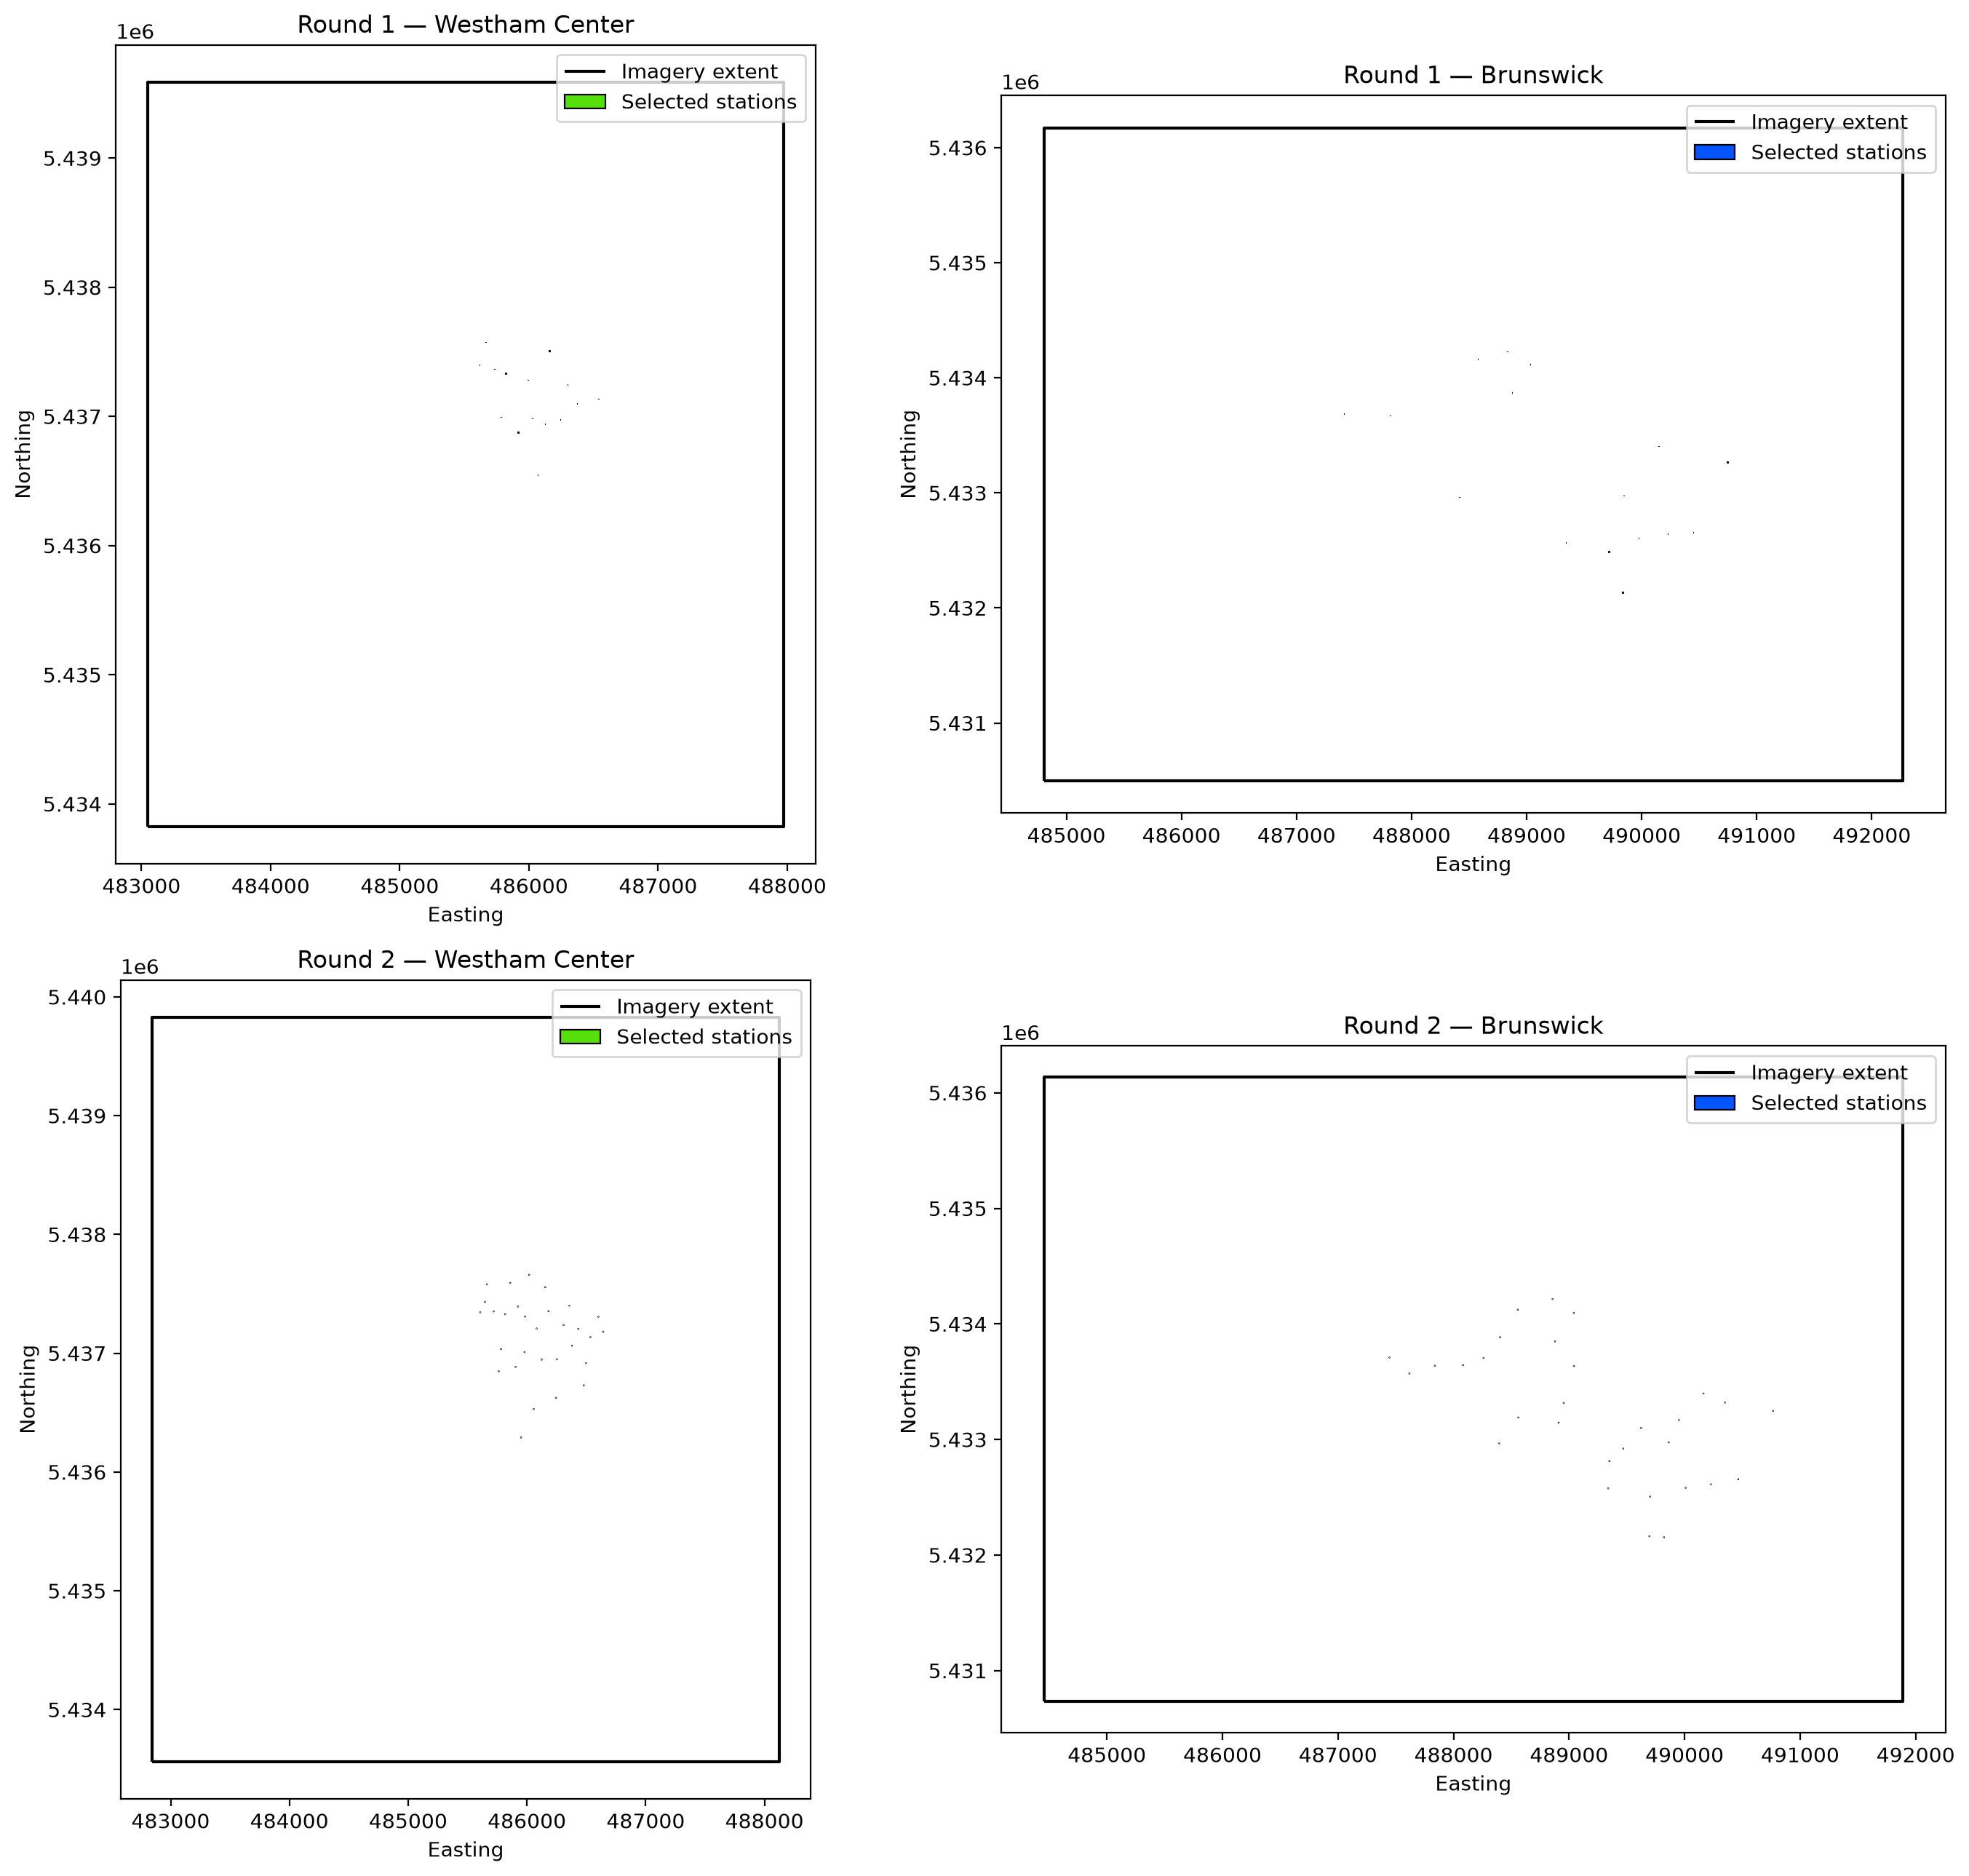

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 13))

for row_index, round_number in enumerate(ROUNDS_OF_INTEREST):
    for column_index, site in enumerate(["westham", "brunswick"]):
        ax = axes[row_index, column_index]
        key = (round_number, site)

        imagery_footprints[key].boundary.plot(
            ax=ax,
            color="black",
            linewidth=1.5,
            label="Imagery extent",
        )

        selected_stations[key].plot(
            ax=ax,
            color=SITE_COLORS[site],
            edgecolor="black",
            linewidth=0.8,
            label="Selected stations",
        )

        ax.set_title(
            f"Round {round_number} — {SITE_CONFIG[site]['label']}"
        )
        ax.set_xlabel("Easting")
        ax.set_ylabel("Northing")
        ax.set_aspect("equal")
        ax.legend()

plt.tight_layout()
plt.show()

## 9. Pixel-spectrum extraction and calibration functions

In [15]:
def spectral_value_columns(wavelengths_nm=WAVELENGTHS_NM):
    return [
        f"value_{int(wavelength)}nm"
        for wavelength in wavelengths_nm
    ]


def empty_spectra_frame(wavelengths_nm=WAVELENGTHS_NM):
    return pd.DataFrame(
        columns=[
            "round",
            "flight_date",
            "site",
            "station_name",
            "image_stage",
            "pixel_id",
            "raster_row",
            "raster_col",
            "x",
            "y",
            *spectral_value_columns(wavelengths_nm),
        ]
    )


def extract_polygon_pixel_spectra(
    src,
    geometry,
    *,
    round_number,
    flight_date,
    site,
    station_name,
    image_stage,
    source_band_indexes,
    wavelengths_nm=WAVELENGTHS_NM,
    all_touched=ALL_TOUCHED,
):
    source_band_indexes = list(source_band_indexes)

    if len(source_band_indexes) != len(wavelengths_nm):
        raise ValueError(
            "Source-band and wavelength counts do not match."
        )

    data, clipped_transform = mask(
        src,
        [mapping(geometry)],
        crop=True,
        all_touched=all_touched,
        filled=False,
        indexes=source_band_indexes,
    )

    data_mask = np.ma.getmaskarray(data)
    raw_data = np.asarray(data.data)

    valid_pixel = (
        ~data_mask.any(axis=0)
        & np.isfinite(raw_data).all(axis=0)
    )

    clipped_rows, clipped_cols = np.where(valid_pixel)

    if len(clipped_rows) == 0:
        return empty_spectra_frame(wavelengths_nm)

    spectra = raw_data[:, valid_pixel].T.astype("float32")

    xs, ys = rasterio.transform.xy(
        clipped_transform,
        clipped_rows,
        clipped_cols,
        offset="center",
    )
    xs = np.asarray(xs)
    ys = np.asarray(ys)

    global_rows, global_cols = rowcol(src.transform, xs, ys)
    global_rows = np.asarray(global_rows, dtype="int64")
    global_cols = np.asarray(global_cols, dtype="int64")

    output = pd.DataFrame(
        spectra,
        columns=spectral_value_columns(wavelengths_nm),
    )

    output.insert(0, "y", ys)
    output.insert(0, "x", xs)
    output.insert(0, "raster_col", global_cols)
    output.insert(0, "raster_row", global_rows)
    output.insert(
        0,
        "pixel_id",
        [
            (
                f"r{round_number}_{site}_{station_name}"
                f"_row{row}_col{col}"
            )
            for row, col in zip(global_rows, global_cols)
        ],
    )
    output.insert(0, "image_stage", image_stage)
    output.insert(0, "station_name", station_name)
    output.insert(0, "site", site)
    output.insert(0, "flight_date", flight_date)
    output.insert(0, "round", round_number)

    return output


def extract_all_station_spectra(
    raster_path,
    station_gdf,
    *,
    round_number,
    site,
    image_stage,
    source_band_indexes,
):
    extracted = []

    with rasterio.open(raster_path) as src:
        for station in station_gdf.itertuples(index=False):
            extracted.append(
                extract_polygon_pixel_spectra(
                    src,
                    station.geometry,
                    round_number=round_number,
                    flight_date=ROUND_DATES[round_number],
                    site=site,
                    station_name=station.station_name,
                    image_stage=image_stage,
                    source_band_indexes=source_band_indexes,
                )
            )

    if not extracted:
        return empty_spectra_frame()

    return pd.concat(extracted, ignore_index=True)


def apply_bandwise_linear_transform(
    spectra_df,
    coefficients,
    *,
    output_stage,
):
    output = spectra_df.copy()

    for coefficient in coefficients.itertuples(index=False):
        value_column = f"value_{int(coefficient.wavelength_nm)}nm"
        output[value_column] = (
            output[value_column].astype("float64")
            * float(coefficient.gain)
            + float(coefficient.offset)
        ).astype("float32")

    output["image_stage"] = output_stage
    return output


def validate_sequential_against_combined(
    original,
    sequential,
    combined_coefficients,
):
    one_step = apply_bandwise_linear_transform(
        original,
        combined_coefficients,
        output_stage="one_step_validation",
    )

    columns = spectral_value_columns()
    maximum_difference = float(
        np.nanmax(
            np.abs(
                sequential[columns].to_numpy(dtype="float64")
                - one_step[columns].to_numpy(dtype="float64")
            )
        )
    )

    if not np.allclose(
        sequential[columns],
        one_step[columns],
        rtol=1e-6,
        atol=1e-7,
    ):
        raise RuntimeError(
            "Sequential and combined calibration results differ."
        )

    return maximum_difference

## 10. Extract all raw imagery

In [16]:
raw_spectra = {}

for round_number in ROUNDS_OF_INTEREST:
    for site in SITE_CONFIG:
        key = (round_number, site)

        raw_spectra[key] = extract_all_station_spectra(
            RAW_RASTER_PATHS[key],
            selected_stations[key],
            round_number=round_number,
            site=site,
            image_stage="uncorrected",
            source_band_indexes=SOURCE_BANDS_11B_TO_10B,
        )

        print(
            f"Round {round_number}, {site}: "
            f"{len(raw_spectra[key])} raw pixel spectra"
        )

Round 1, westham: 1327 raw pixel spectra
Round 1, brunswick: 1341 raw pixel spectra
Round 2, westham: 1374 raw pixel spectra
Round 2, brunswick: 1382 raw pixel spectra


## 11. Build Round 1 calibrated stages

In [17]:
# Round 1 Westham:
# raw May 4 -> Westham May 18 scope -> final correction.
westham_r1_may18_scope = apply_bandwise_linear_transform(
    raw_spectra[(1, "westham")],
    WESTHAM_MAY4_TO_WESTHAM_MAY18,
    output_stage="westham_may18_scope",
)

westham_r1_fully_corrected = apply_bandwise_linear_transform(
    westham_r1_may18_scope,
    WESTHAM_MAY18_TO_FINAL,
    output_stage="fully_corrected",
)

westham_r1_combined_difference = validate_sequential_against_combined(
    raw_spectra[(1, "westham")],
    westham_r1_fully_corrected,
    WESTHAM_MAY4_TO_FINAL,
)

print(
    "Round 1 Westham maximum sequential/combined difference:",
    westham_r1_combined_difference,
)

Round 1 Westham maximum sequential/combined difference: 7.450580596923828e-09


In [18]:
# Round 1 Brunswick:
# raw May 4 -> Westham May 4 scope
# -> Westham May 18 scope -> final correction.
brunswick_r1_may4_scope = apply_bandwise_linear_transform(
    raw_spectra[(1, "brunswick")],
    BRUNSWICK_MAY4_TO_WESTHAM_MAY4,
    output_stage="westham_may4_scope",
)

brunswick_r1_may18_scope = apply_bandwise_linear_transform(
    brunswick_r1_may4_scope,
    WESTHAM_MAY4_TO_WESTHAM_MAY18,
    output_stage="westham_may18_scope",
)

brunswick_r1_fully_corrected = apply_bandwise_linear_transform(
    brunswick_r1_may18_scope,
    WESTHAM_MAY18_TO_FINAL,
    output_stage="fully_corrected",
)

brunswick_r1_combined_difference = validate_sequential_against_combined(
    raw_spectra[(1, "brunswick")],
    brunswick_r1_fully_corrected,
    BRUNSWICK_MAY4_TO_FINAL,
)

print(
    "Round 1 Brunswick maximum sequential/combined difference:",
    brunswick_r1_combined_difference,
)

Round 1 Brunswick maximum sequential/combined difference: 1.4901161193847656e-08


## 12. Build Round 2 calibrated stages

In [19]:
# Round 2 Westham final values come from the existing corrected raster.
westham_r2_fully_corrected = extract_all_station_spectra(
    WESTHAM_ROUND2_CORRECTED_PATH,
    selected_stations[(2, "westham")],
    round_number=2,
    site="westham",
    image_stage="fully_corrected",
    source_band_indexes=SOURCE_BANDS_10B,
)

print(
    "Round 2 Westham corrected pixel spectra:",
    len(westham_r2_fully_corrected),
)

Round 2 Westham corrected pixel spectra: 1374


In [20]:
# Round 2 Brunswick:
# raw May 18 -> Westham May 18 scope -> final correction.
brunswick_r2_may18_scope = apply_bandwise_linear_transform(
    raw_spectra[(2, "brunswick")],
    BRUNSWICK_MAY18_TO_WESTHAM_MAY18,
    output_stage="westham_may18_scope",
)

brunswick_r2_fully_corrected = apply_bandwise_linear_transform(
    brunswick_r2_may18_scope,
    WESTHAM_MAY18_TO_FINAL,
    output_stage="fully_corrected",
)

brunswick_r2_combined_difference = validate_sequential_against_combined(
    raw_spectra[(2, "brunswick")],
    brunswick_r2_fully_corrected,
    BRUNSWICK_MAY18_TO_FINAL,
)

print(
    "Round 2 Brunswick maximum sequential/combined difference:",
    brunswick_r2_combined_difference,
)

Round 2 Brunswick maximum sequential/combined difference: 1.4901161193847656e-08


## 13. Combine stages and perform pixel-count QC

In [21]:
spectra_pixels_wide = pd.concat(
    [
        raw_spectra[(1, "westham")],
        westham_r1_may18_scope,
        westham_r1_fully_corrected,

        raw_spectra[(1, "brunswick")],
        brunswick_r1_may4_scope,
        brunswick_r1_may18_scope,
        brunswick_r1_fully_corrected,

        raw_spectra[(2, "westham")],
        westham_r2_fully_corrected,

        raw_spectra[(2, "brunswick")],
        brunswick_r2_may18_scope,
        brunswick_r2_fully_corrected,
    ],
    ignore_index=True,
)

pixel_counts = (
    spectra_pixels_wide
    .groupby(
        ["round", "site", "station_name", "image_stage"]
    )
    .size()
    .rename("pixel_count")
    .reset_index()
)

pixel_count_pivot = (
    pixel_counts
    .pivot(
        index=["round", "site", "station_name"],
        columns="image_stage",
        values="pixel_count",
    )
)

display(pixel_count_pivot)

image_stage                   fully_corrected  uncorrected  \
round site      station_name                                 
1     brunswick B1                       49.0         49.0   
                B10                      42.0         42.0   
                B11                      42.0         42.0   
                B12                      36.0         36.0   
                B13                      36.0         36.0   
...                                       ...          ...   
2     westham   W5                       48.0         48.0   
                W6                       43.0         43.0   
                W7                       42.0         42.0   
                W8                       44.0         44.0   
                W9                       45.0         45.0   

image_stage                   westham_may18_scope  westham_may4_scope  
round site      station_name                                           
1     brunswick B1                           49.0                49.0  
                B10                          42.0                42.0  
                B11                          42.0                42.0  
                B12                          36.0                36.0  
                B13                          36.0                36.0  
...                                           ...                 ...  
2     westham   W5                            NaN                 NaN  
                W6                            NaN                 NaN  
                W7                            NaN                 NaN  
                W8                            NaN                 NaN  
                W9                            NaN                 NaN  

[120 rows x 4 columns]

In [22]:
for key, required_stages in STAGE_ORDER_BY_ROUND_SITE.items():
    round_number, site = key

    available = pixel_count_pivot.loc[
        (round_number, site),
        required_stages,
    ]

    if available.isna().any().any():
        raise RuntimeError(
            f"Missing stage for Round {round_number}, {site}."
        )

    if (available <= 0).any().any():
        raise RuntimeError(
            f"Zero valid pixels for Round {round_number}, {site}."
        )

    # Derived stages should preserve pixel counts. Round 2 Westham uses a
    # separately stored raster, so its valid-pixel count is checked but not
    # required to be identical.
    if key != (2, "westham"):
        if not available.nunique(axis=1).eq(1).all():
            raise RuntimeError(
                f"Derived stages changed pixel counts for "
                f"Round {round_number}, {site}."
            )

## 14. Convert imagery spectra to long format and summarize

In [23]:
value_to_wavelength = {
    f"value_{int(wavelength)}nm": int(wavelength)
    for wavelength in WAVELENGTHS_NM
}

spectra_pixels_long = (
    spectra_pixels_wide
    .melt(
        id_vars=[
            "round",
            "flight_date",
            "site",
            "station_name",
            "image_stage",
            "pixel_id",
            "raster_row",
            "raster_col",
            "x",
            "y",
        ],
        value_vars=list(value_to_wavelength),
        var_name="spectral_column",
        value_name="value",
    )
)

spectra_pixels_long["wavelength_nm"] = (
    spectra_pixels_long["spectral_column"]
    .map(value_to_wavelength)
    .astype("int64")
)

spectra_pixels_long["band_name"] = (
    spectra_pixels_long["wavelength_nm"]
    .map(dict(zip(WAVELENGTHS_NM, BAND_NAMES)))
)

spectra_pixels_long = (
    spectra_pixels_long[
        [
            "round",
            "flight_date",
            "site",
            "station_name",
            "image_stage",
            "pixel_id",
            "raster_row",
            "raster_col",
            "x",
            "y",
            "band_name",
            "wavelength_nm",
            "value",
        ]
    ]
    .sort_values(
        [
            "round",
            "site",
            "station_name",
            "image_stage",
            "raster_row",
            "raster_col",
            "wavelength_nm",
        ]
    )
    .reset_index(drop=True)
)

station_spectral_summary = (
    spectra_pixels_long
    .groupby(
        [
            "round",
            "flight_date",
            "site",
            "station_name",
            "image_stage",
            "band_name",
            "wavelength_nm",
        ],
        as_index=False,
        observed=True,
    )
    .agg(
        pixel_count=("value", "count"),
        mean=("value", "mean"),
        median=("value", "median"),
        std=("value", "std"),
        minimum=("value", "min"),
        q25=("value", lambda x: x.quantile(0.25)),
        q75=("value", lambda x: x.quantile(0.75)),
        maximum=("value", "max"),
    )
    .sort_values(
        [
            "round",
            "site",
            "station_name",
            "image_stage",
            "wavelength_nm",
        ]
    )
    .reset_index(drop=True)
)

display(station_spectral_summary.head(20))

,round,flight_date,site,station_name,image_stage,band_name,wavelength_nm,pixel_count,mean,median,std,minimum,q25,q75,maximum
0,1,2026-05-04,brunswick,B1,fully_corrected,B1,444,49,0.051710,0.052128,0.003975,0.040807,0.049607,0.054178,0.058521
1,1,2026-05-04,brunswick,B1,fully_corrected,B2,475,49,0.062407,0.062646,0.004120,0.052015,0.060162,0.064960,0.070194
2,1,2026-05-04,brunswick,B1,fully_corrected,B3,531,49,0.074066,0.074097,0.003581,0.064214,0.072608,0.076737,0.081644
3,1,2026-05-04,brunswick,B1,fully_corrected,B4,560,49,0.089548,0.090058,0.003848,0.074837,0.088916,0.091732,0.095184
4,1,2026-05-04,brunswick,B1,fully_corrected,B5,650,49,0.080584,0.080881,0.003407,0.070880,0.079404,0.082508,0.086165
5,1,2026-05-04,brunswick,B1,fully_corrected,B6,668,49,0.072442,0.072900,0.002495,0.064999,0.071118,0.074012,0.078709
6,1,2026-05-04,brunswick,B1,fully_corrected,B7,705,49,0.084876,0.084974,0.003863,0.074662,0.082925,0.087868,0.091935
7,1,2026-05-04,brunswick,B1,fully_corrected,B8,717,49,0.090514,0.090942,0.004035,0.076844,0.089134,0.092672,0.098142
8,1,2026-05-04,brunswick,B1,fully_corrected,B9,740,49,0.089067,0.089263,0.005028,0.072924,0.087356,0.092964,0.097552
9,1,2026-05-04,brunswick,B1,fully_corrected,B10,842,49,0.097880,0.098989,0.005036,0.079594,0.094980,0.100613,0.107635


## 15. Plot station mean spectra by round and site

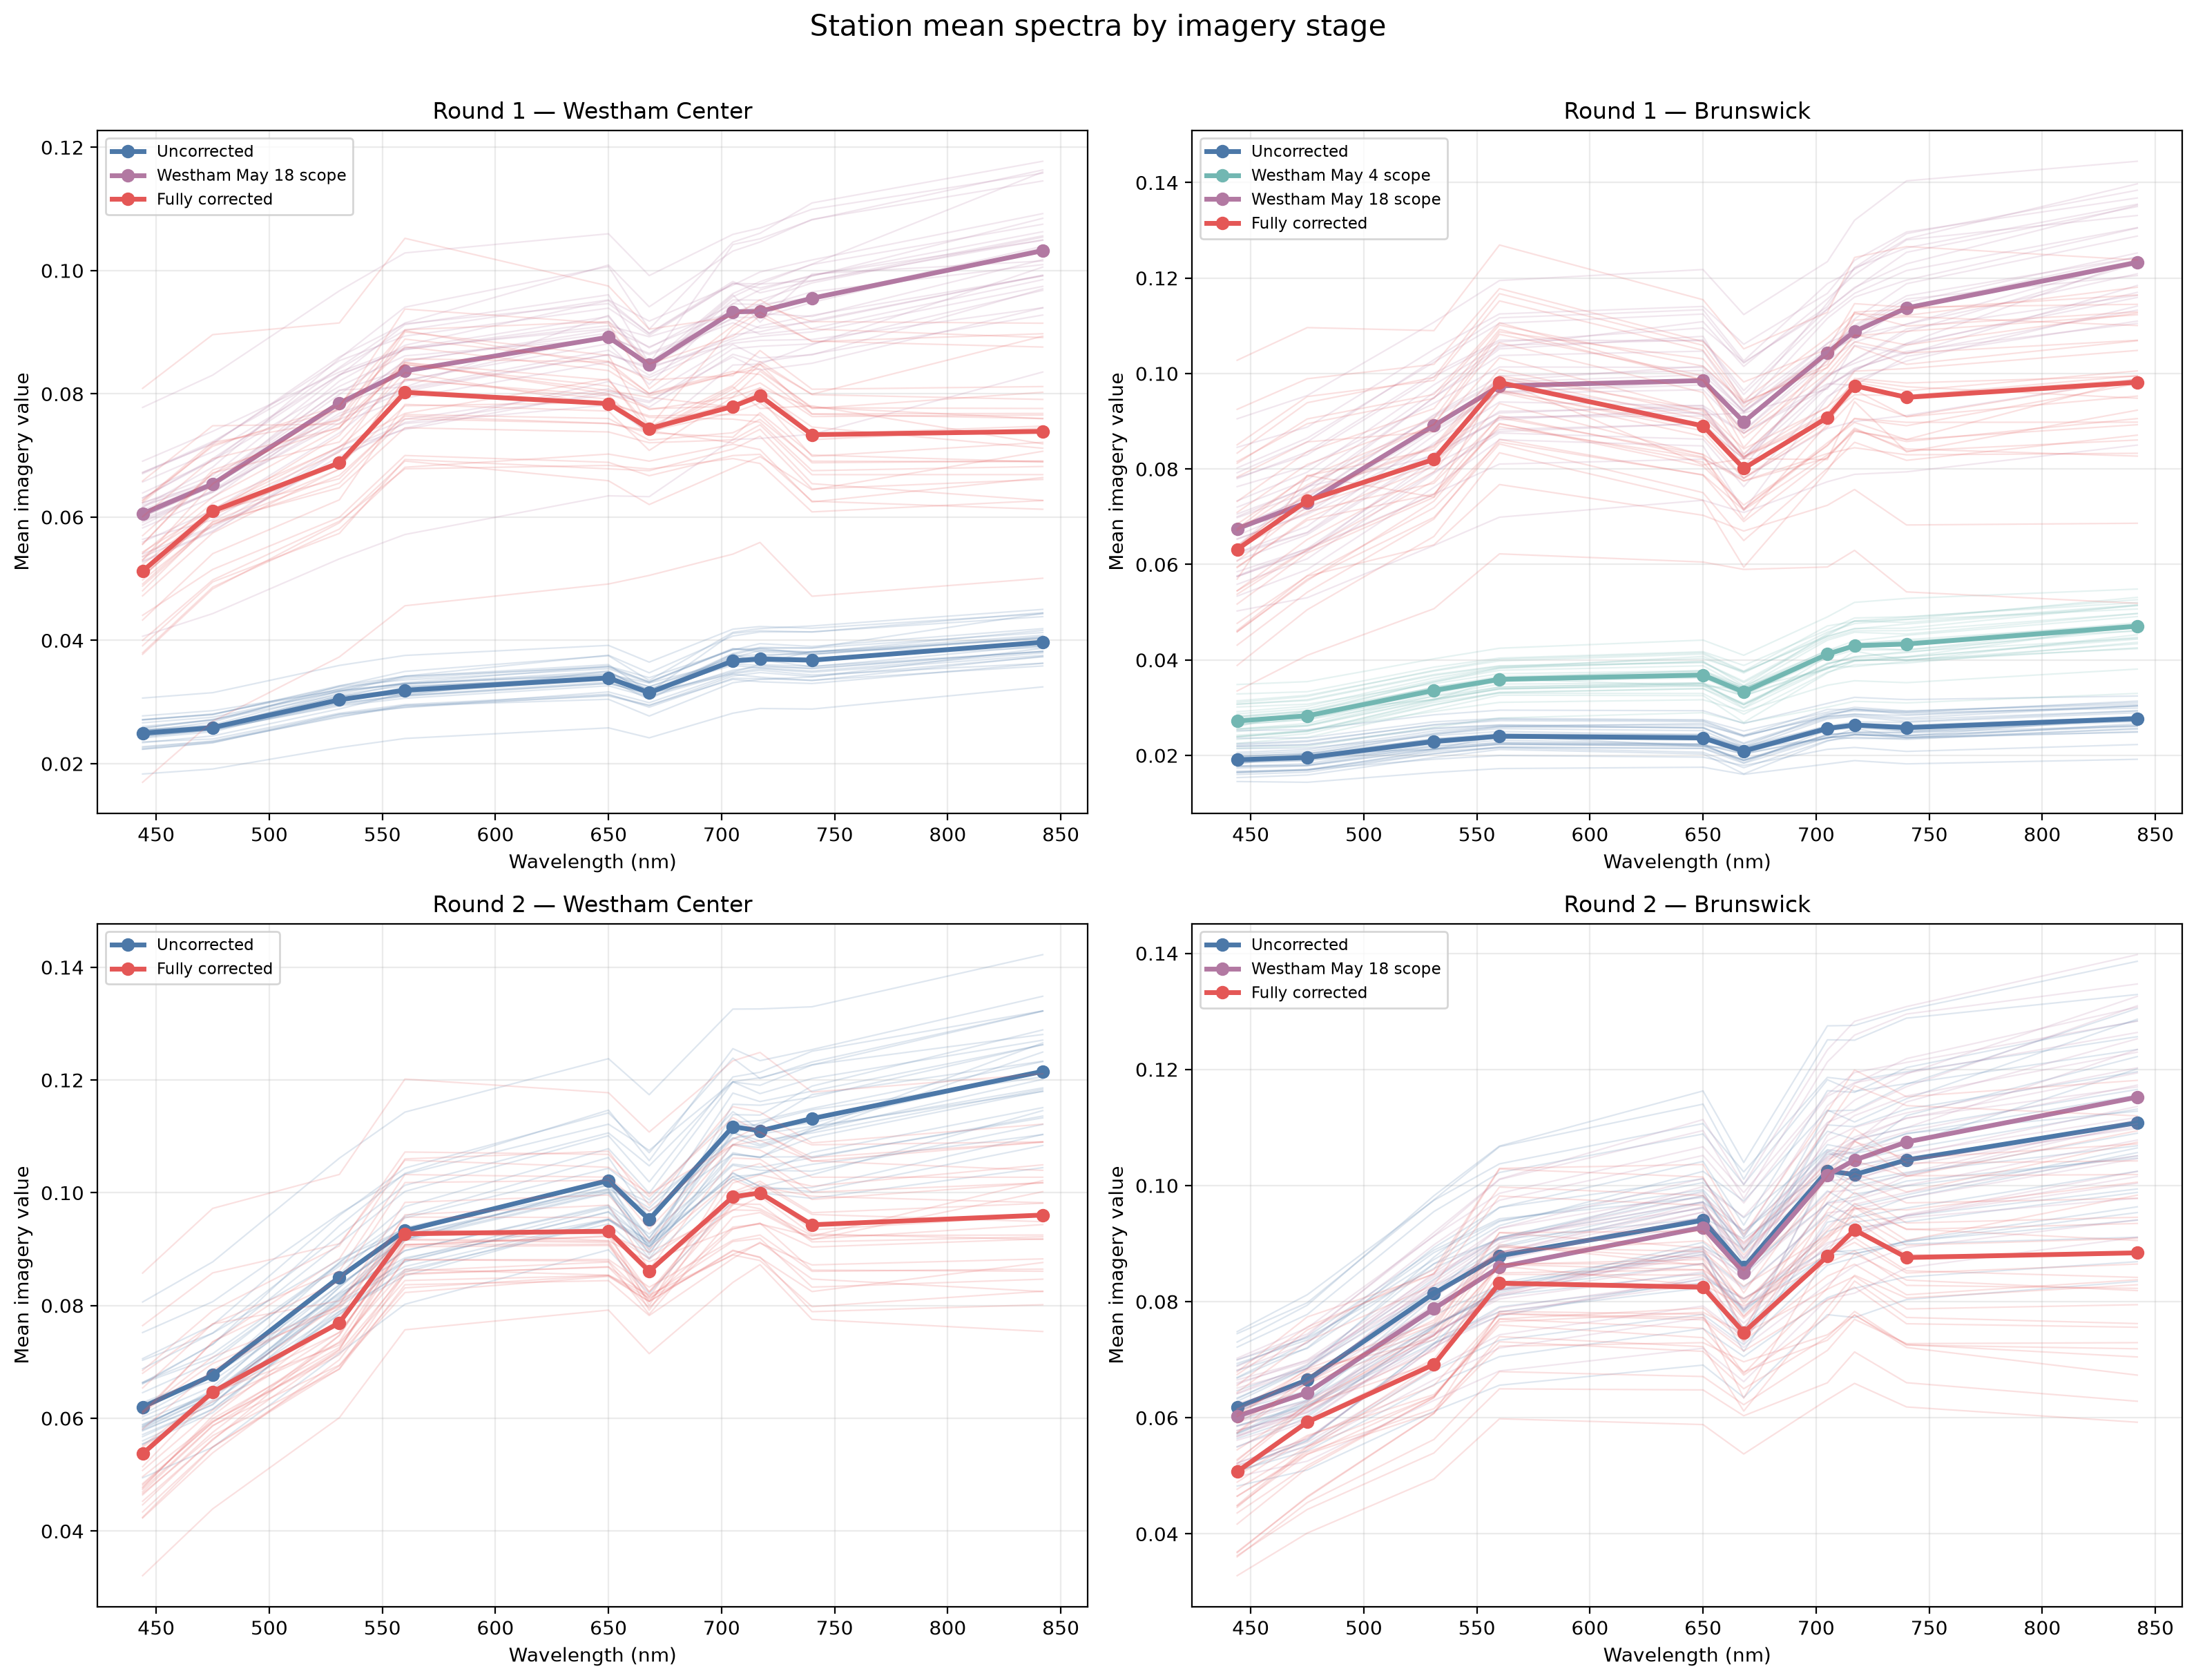

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharey=False)

for row_index, round_number in enumerate(ROUNDS_OF_INTEREST):
    for column_index, site in enumerate(["westham", "brunswick"]):
        ax = axes[row_index, column_index]
        key = (round_number, site)

        site_data = station_spectral_summary.loc[
            station_spectral_summary["round"].eq(round_number)
            & station_spectral_summary["site"].eq(site)
        ]

        for image_stage in STAGE_ORDER_BY_ROUND_SITE[key]:
            stage_data = site_data.loc[
                site_data["image_stage"].eq(image_stage)
            ]

            for _, station_data in stage_data.groupby(
                "station_name",
                sort=False,
            ):
                station_data = station_data.sort_values(
                    "wavelength_nm"
                )
                ax.plot(
                    station_data["wavelength_nm"],
                    station_data["mean"],
                    alpha=0.18,
                    linewidth=0.8,
                    color=STAGE_COLORS[image_stage],
                )

            overall_mean = (
                stage_data
                .groupby("wavelength_nm", as_index=False)["mean"]
                .mean()
                .sort_values("wavelength_nm")
            )

            ax.plot(
                overall_mean["wavelength_nm"],
                overall_mean["mean"],
                marker="o",
                linewidth=2.5,
                color=STAGE_COLORS[image_stage],
                label=STAGE_LABELS[image_stage],
            )

        ax.set_title(
            f"Round {round_number} — {SITE_CONFIG[site]['label']}"
        )
        ax.set_xlabel("Wavelength (nm)")
        ax.set_ylabel("Mean imagery value")
        ax.grid(alpha=0.25)
        ax.legend(fontsize="small")

fig.suptitle(
    "Station mean spectra by imagery stage",
    y=1.01,
    fontsize=15,
)
plt.tight_layout()
plt.show()

## 16. Validate the stored Round 2 Westham corrected raster

In [25]:
def build_paired_calibration_table(
    before_df,
    after_df,
    calibration_df,
):
    pair_keys = [
        "round",
        "site",
        "station_name",
        "raster_row",
        "raster_col",
    ]

    paired = before_df.merge(
        after_df,
        on=pair_keys,
        how="inner",
        suffixes=("_before", "_after"),
        validate="one_to_one",
    )

    records = []

    for coefficient in calibration_df.itertuples(index=False):
        wavelength = int(coefficient.wavelength_nm)
        before_column = f"value_{wavelength}nm_before"
        after_column = f"value_{wavelength}nm_after"

        result = paired[
            pair_keys + [before_column, after_column]
        ].copy()

        result = result.rename(
            columns={
                before_column: "before_value",
                after_column: "after_value",
            }
        )
        result["band_name"] = coefficient.band_name
        result["wavelength_nm"] = wavelength
        result["expected_after_value"] = (
            result["before_value"] * coefficient.gain
            + coefficient.offset
        )
        result["calibration_residual"] = (
            result["after_value"]
            - result["expected_after_value"]
        )
        records.append(result)

    return pd.concat(records, ignore_index=True)


if WESTHAM_ROUND2_GRIDS_MATCH:
    westham_r2_paired_calibration = build_paired_calibration_table(
        raw_spectra[(2, "westham")],
        westham_r2_fully_corrected,
        WESTHAM_MAY18_TO_FINAL,
    )

    westham_r2_calibration_residual_summary = (
        westham_r2_paired_calibration
        .groupby(
            ["band_name", "wavelength_nm"],
            as_index=False,
            observed=True,
        )
        .agg(
            paired_pixel_count=("calibration_residual", "count"),
            mean_residual=("calibration_residual", "mean"),
            residual_std=("calibration_residual", "std"),
            mean_absolute_residual=(
                "calibration_residual",
                lambda x: x.abs().mean(),
            ),
            maximum_absolute_residual=(
                "calibration_residual",
                lambda x: x.abs().max(),
            ),
        )
        .sort_values("wavelength_nm")
    )

    display(westham_r2_calibration_residual_summary)
else:
    westham_r2_paired_calibration = pd.DataFrame()
    westham_r2_calibration_residual_summary = pd.DataFrame()
    print("Validation skipped because the grids differ.")

,band_name,wavelength_nm,paired_pixel_count,mean_residual,residual_std,mean_absolute_residual,maximum_absolute_residual
0,B1,444,1374,0.0,0.0,0.0,0.0
2,B2,475,1374,0.0,0.0,0.0,0.0
3,B3,531,1374,0.0,0.0,0.0,0.0
4,B4,560,1374,0.0,0.0,0.0,0.0
5,B5,650,1374,0.0,0.0,0.0,0.0
6,B6,668,1374,0.0,0.0,0.0,0.0
7,B7,705,1374,0.0,0.0,0.0,0.0
8,B8,717,1374,0.0,0.0,0.0,0.0
9,B9,740,1374,0.0,0.0,0.0,0.0
1,B10,842,1374,0.0,0.0,0.0,0.0


## 17. Load Round 1 and Round 2 sample type R field spectra

In [26]:
SITES = ["brunswick", "westham"]

scan_cols = [
    "station_id",
    "round",
    "sample_type",
    "scan_id",
    "pair_id",
]

field_source_frames = []

for site in SITES:
    path_parquet = (
        path_spectra_processed_folder
        / f"{site}_reflectance_common_wavelengths_scans.parquet"
    )
    field_source_frames.append(
        read_df_from_parquet(path_parquet).copy()
    )

field_spectra_with_metadata = pd.concat(
    field_source_frames,
    ignore_index=True,
)

field_spectral_matrix = to_spectral_matrix(
    field_spectra_with_metadata,
    scan_cols=scan_cols,
)

field_spectral_matrix_10b = resample_spectra_to_micasense_10B(
    field_spectral_matrix
)

field_r = field_spectral_matrix_10b.T

round_values = pd.to_numeric(
    field_r.index.get_level_values("round"),
    errors="coerce",
)
sample_type_values = (
    field_r.index
    .get_level_values("sample_type")
    .astype(str)
    .str.strip()
    .str.upper()
)

field_r = field_r.loc[
    np.isin(round_values, ROUNDS_OF_INTEREST)
    & np.asarray(
        sample_type_values == SAMPLE_TYPE_OF_INTEREST,
        dtype=bool,
    )
]

print("Round 1/2, sample type R scans:", len(field_r))
display(field_r.head())

Round 1/2, sample type R scans: 2400


wavelength_nm                                      444       475       531  \
station_id round sample_type scan_id pair_id                                 
B9         1     R           0       0        0.041942  0.050375  0.073353   
                             1       0        0.043118  0.051341  0.074149   
                             2       1        0.045860  0.054453  0.077763   
                             3       1        0.046504  0.055122  0.079181   
                             4       2        0.039972  0.049177  0.072757   

wavelength_nm                                      560       650       668  \
station_id round sample_type scan_id pair_id                                 
B9         1     R           0       0        0.086688  0.096481  0.085349   
                             1       0        0.087458  0.097266  0.085999   
                             2       1        0.090667  0.100088  0.089272   
                             3       1        0.092964  0.102024  0.089631   
                             4       2        0.085914  0.097663  0.089010   

wavelength_nm                                      705       717       740  \
station_id round sample_type scan_id pair_id                                 
B9         1     R           0       0        0.107595  0.110575  0.113878   
                             1       0        0.108424  0.111394  0.114607   
                             2       1        0.110321  0.113060  0.116366   
                             3       1        0.113588  0.116649  0.120017   
                             4       2        0.108493  0.111174  0.114366   

wavelength_nm                                      842  
station_id round sample_type scan_id pair_id            
B9         1     R           0       0        0.122656  
                             1       0        0.123336  
                             2       1        0.124574  
                             3       1        0.128534  
                             4       2        0.123093

In [27]:
field_station_mean_wide = (
    field_r
    .groupby(["station_id", "round"])
    .mean()
)

field_station_std_wide = (
    field_r
    .groupby(["station_id", "round"])
    .std()
)

field_mean_long = (
    field_station_mean_wide
    .reset_index()
    .melt(
        id_vars=["station_id", "round"],
        var_name="wavelength_nm",
        value_name="ground_truth_mean",
    )
    .rename(columns={"station_id": "station_name"})
)

field_std_long = (
    field_station_std_wide
    .reset_index()
    .melt(
        id_vars=["station_id", "round"],
        var_name="wavelength_nm",
        value_name="ground_truth_std",
    )
    .rename(columns={"station_id": "station_name"})
)

for dataframe in [field_mean_long, field_std_long]:
    dataframe["station_name"] = (
        dataframe["station_name"]
        .astype("string")
        .str.strip()
    )
    dataframe["round"] = pd.to_numeric(
        dataframe["round"],
        errors="raise",
    ).astype("int64")
    dataframe["wavelength_nm"] = pd.to_numeric(
        dataframe["wavelength_nm"],
        errors="raise",
    ).round().astype("int64")

field_summary_long = field_mean_long.merge(
    field_std_long,
    on=["station_name", "round", "wavelength_nm"],
    how="left",
    validate="one_to_one",
)

display(field_summary_long.head())

,station_name,round,wavelength_nm,ground_truth_mean,ground_truth_std
0,B1,1,444,0.038055,0.002397
1,B1,2,444,0.062701,0.006584
2,B10,1,444,0.047268,0.005981
3,B10,2,444,0.060712,0.003992
4,B11,1,444,0.035086,0.003130


## 18. Merge imagery and field summaries

In [28]:
imagery_vs_field = (
    station_spectral_summary
    .merge(
        field_summary_long,
        on=["station_name", "round", "wavelength_nm"],
        how="inner",
        validate="many_to_one",
    )
    .sort_values(
        [
            "round",
            "site",
            "station_name",
            "image_stage",
            "wavelength_nm",
        ]
    )
    .reset_index(drop=True)
)

print("Matched imagery/field records:", len(imagery_vs_field))
display(
    imagery_vs_field
    .groupby(["round", "site"])["station_name"]
    .nunique()
    .rename("matched_station_count")
    .to_frame()
)

display(imagery_vs_field.head())

Matched imagery/field records: 3600


matched_station_count
round site                            
1     brunswick                     30
      westham                       30
2     brunswick                     30
      westham                       30

,round,flight_date,site,station_name,image_stage,band_name,wavelength_nm,pixel_count,mean,median,std,minimum,q25,q75,maximum,ground_truth_mean,ground_truth_std
0,1,2026-05-04,brunswick,B1,fully_corrected,B1,444,49,0.051710,0.052128,0.003975,0.040807,0.049607,0.054178,0.058521,0.038055,0.002397
1,1,2026-05-04,brunswick,B1,fully_corrected,B2,475,49,0.062407,0.062646,0.004120,0.052015,0.060162,0.064960,0.070194,0.045220,0.002411
2,1,2026-05-04,brunswick,B1,fully_corrected,B3,531,49,0.074066,0.074097,0.003581,0.064214,0.072608,0.076737,0.081644,0.064972,0.002727
3,1,2026-05-04,brunswick,B1,fully_corrected,B4,560,49,0.089548,0.090058,0.003848,0.074837,0.088916,0.091732,0.095184,0.075927,0.002984
4,1,2026-05-04,brunswick,B1,fully_corrected,B5,650,49,0.080584,0.080881,0.003407,0.070880,0.079404,0.082508,0.086165,0.083512,0.002724


## 19. Plot imagery and field spectra

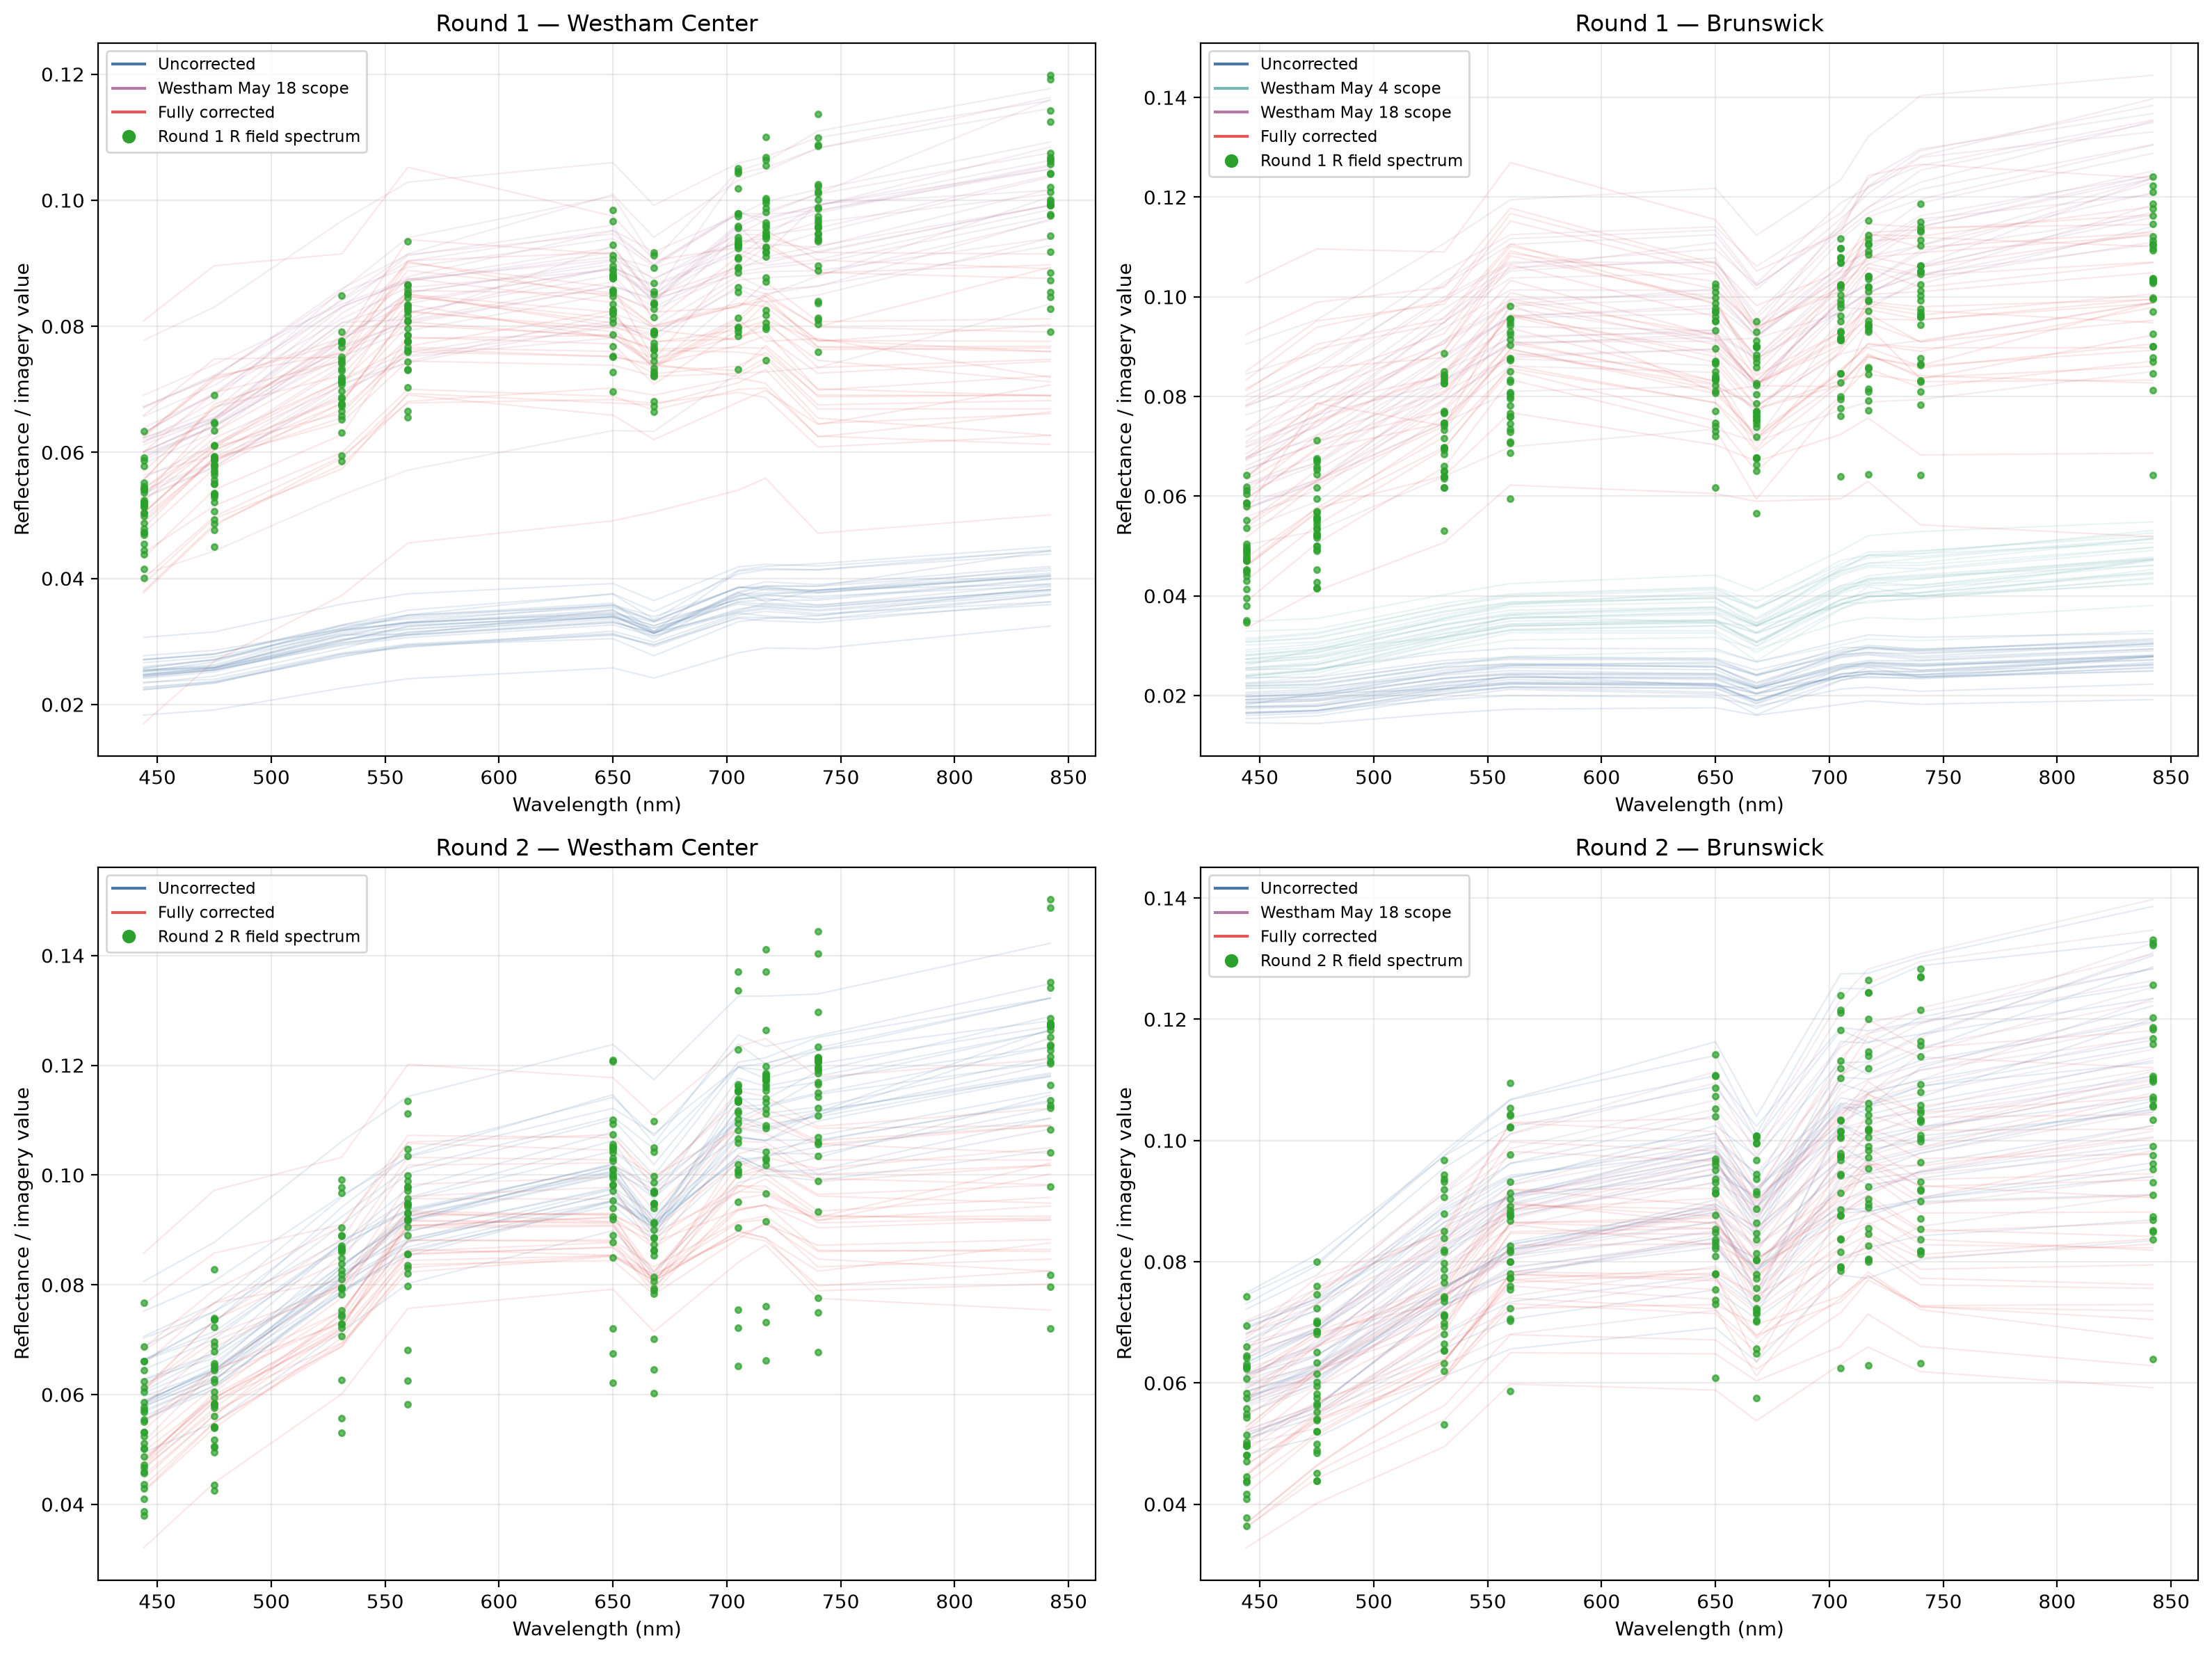

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharey=False)

for row_index, round_number in enumerate(ROUNDS_OF_INTEREST):
    for column_index, site in enumerate(["westham", "brunswick"]):
        ax = axes[row_index, column_index]
        key = (round_number, site)

        site_imagery = station_spectral_summary.loc[
            station_spectral_summary["round"].eq(round_number)
            & station_spectral_summary["site"].eq(site)
        ]

        site_field = imagery_vs_field.loc[
            imagery_vs_field["round"].eq(round_number)
            & imagery_vs_field["site"].eq(site)
        ]

        for image_stage in STAGE_ORDER_BY_ROUND_SITE[key]:
            stage_data = site_imagery.loc[
                site_imagery["image_stage"].eq(image_stage)
            ]

            for _, station_data in stage_data.groupby(
                "station_name",
                sort=False,
            ):
                station_data = station_data.sort_values(
                    "wavelength_nm"
                )
                ax.plot(
                    station_data["wavelength_nm"],
                    station_data["mean"],
                    alpha=0.14,
                    linewidth=0.8,
                    color=STAGE_COLORS[image_stage],
                )

        unique_field = site_field[
            [
                "station_name",
                "wavelength_nm",
                "ground_truth_mean",
            ]
        ].drop_duplicates()

        for _, station_data in unique_field.groupby(
            "station_name",
            sort=False,
        ):
            station_data = station_data.sort_values("wavelength_nm")
            ax.plot(
                station_data["wavelength_nm"],
                station_data["ground_truth_mean"],
                marker="o",
                linestyle="none",
                markersize=3,
                alpha=0.7,
                color="#2CA02C",
            )

        for image_stage in STAGE_ORDER_BY_ROUND_SITE[key]:
            ax.plot(
                [],
                [],
                color=STAGE_COLORS[image_stage],
                label=STAGE_LABELS[image_stage],
            )

        ax.plot(
            [],
            [],
            marker="o",
            linestyle="none",
            color="#2CA02C",
            label=f"Round {round_number} R field spectrum",
        )

        ax.set_title(
            f"Round {round_number} — {SITE_CONFIG[site]['label']}"
        )
        ax.set_xlabel("Wavelength (nm)")
        ax.set_ylabel("Reflectance / imagery value")
        ax.grid(alpha=0.25)
        ax.legend(fontsize="small")

plt.tight_layout()
plt.show()

## 20. Detailed imagery-versus-field scatter plots

In [30]:
MARKER_SIZE_DEFAULT = 12
MARKER_SIZE_HIGHLIGHT = 100

BAND_COLORS = dict(
    zip(
        BAND_NAMES,
        [
            "#4C78A8", "#F58518", "#E45756", "#72B7B2",
            "#54A24B", "#EECA3B", "#B279A2", "#FF9DA6",
            "#9D755D", "#BAB0AC",
        ],
    )
)

BAND_WAVELENGTHS = dict(zip(BAND_NAMES, WAVELENGTHS_NM))

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 14))

for row_index, round_number in enumerate(ROUNDS_OF_INTEREST):
    for column_index, site in enumerate(["westham", "brunswick"]):
        ax = axes[row_index, column_index]
        key = (round_number, site)

        site_data = imagery_vs_field.loc[
            imagery_vs_field["round"].eq(round_number)
            & imagery_vs_field["site"].eq(site)
        ].copy()

        highlighted = set(STATIONS_TO_HIGHLIGHT[key])

        for row in site_data.itertuples(index=False):
            if (
                not np.isfinite(row.ground_truth_mean)
                or not np.isfinite(row.mean)
            ):
                continue

            is_highlighted = row.station_name in highlighted

            x_error = (
                row.ground_truth_std
                if np.isfinite(row.ground_truth_std)
                else None
            )
            y_error = (
                row.std
                if np.isfinite(row.std)
                else None
            )

            ax.errorbar(
                row.ground_truth_mean,
                row.mean,
                xerr=x_error,
                yerr=y_error,
                fmt="none",
                ecolor="grey",
                elinewidth=0.8,
                capsize=0,
                alpha=0.50 if is_highlighted else 0.10,
                zorder=1,
            )

            ax.scatter(
                row.ground_truth_mean,
                row.mean,
                marker=STAGE_MARKERS[row.image_stage],
                s=(
                    MARKER_SIZE_HIGHLIGHT
                    if is_highlighted
                    else MARKER_SIZE_DEFAULT
                ),
                color=BAND_COLORS[row.band_name],
                edgecolor="black" if is_highlighted else "none",
                linewidth=0.6 if is_highlighted else 0,
                alpha=1.0 if is_highlighted else 0.65,
                zorder=3 if is_highlighted else 2,
            )

        finite_values = np.concatenate(
            [
                site_data["ground_truth_mean"]
                .replace([np.inf, -np.inf], np.nan)
                .dropna()
                .to_numpy(),
                site_data["mean"]
                .replace([np.inf, -np.inf], np.nan)
                .dropna()
                .to_numpy(),
            ]
        )

        if finite_values.size:
            data_min = float(finite_values.min())
            data_max = float(finite_values.max())
            padding = 0.05 * (data_max - data_min)

            if padding == 0:
                padding = 0.01

            lower = data_min - padding
            upper = data_max + padding

            ax.plot(
                [lower, upper],
                [lower, upper],
                "k--",
                linewidth=1.5,
                zorder=0,
            )
            ax.set_xlim(lower, upper)
            ax.set_ylim(lower, upper)

        ax.set_title(
            f"Round {round_number} — {SITE_CONFIG[site]['label']}"
        )
        ax.set_xlabel("Ground-truth reflectance")
        ax.set_ylabel("Imagery station mean")
        ax.set_aspect("equal", adjustable="box")
        ax.grid(alpha=0.2)

band_handles = [
    Patch(
        facecolor=BAND_COLORS[band_name],
        edgecolor="none",
        label=f"{band_name} ({BAND_WAVELENGTHS[band_name]} nm)",
    )
    for band_name in BAND_NAMES
]

stage_handles = [
    Line2D(
        [0],
        [0],
        marker=STAGE_MARKERS[stage],
        linestyle="none",
        markerfacecolor="grey",
        markeredgecolor="black",
        markersize=8,
        label=STAGE_LABELS[stage],
    )
    for stage in STAGE_MARKERS
]

size_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="none",
        markerfacecolor="grey",
        markeredgecolor="black",
        markersize=np.sqrt(MARKER_SIZE_HIGHLIGHT),
        label="Highlighted station",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="none",
        markerfacecolor="grey",
        markeredgecolor="none",
        markersize=np.sqrt(MARKER_SIZE_DEFAULT),
        label="Other station",
    ),
    Line2D(
        [0],
        [0],
        linestyle="--",
        color="black",
        linewidth=1.5,
        label="1:1 line",
    ),
]

fig.legend(
    handles=band_handles + stage_handles + size_handles,
    bbox_to_anchor=(1.01, 0.5),
    loc="center left",
    fontsize="small",
    title="Band, stage, and station status",
)

fig.suptitle(
    "Imagery station means versus field reflectance",
    fontsize=15,
    y=1.01,
)

plt.tight_layout()
plt.show()

## 21. Stage-by-stage scatter plots for each area and flight date

This section creates one figure for each area/date combination. Each
subplot contains a single calibration stage:

- original imagery values use circles;
- intermediate scope transformations use triangles;
- final corrected values use diamonds.

Band colors, error bars, highlighted-station sizing, and 1:1 lines are
retained. Each panel reports R² and RMSE for all matched stations and
for the highlighted subset where available.

In [ ]:
STAGE_ROLE_MARKERS = {
    "original": "o",
    "intermediate": "^",
    "final": "D",
}

STAGE_ROLE_LABELS = {
    "original": "Original values",
    "intermediate": "Intermediate scope",
    "final": "Final corrected",
}


def stage_role(image_stage):
    if image_stage == "uncorrected":
        return "original"
    if image_stage == "fully_corrected":
        return "final"
    return "intermediate"


def calculate_panel_metrics(data):
    valid = data[
        ["ground_truth_mean", "mean"]
    ].replace(
        [np.inf, -np.inf],
        np.nan,
    ).dropna()

    if len(valid) < 2:
        return {
            "n": len(valid),
            "r2": np.nan,
            "rmse": np.nan,
        }

    observed = valid["ground_truth_mean"].to_numpy()
    predicted = valid["mean"].to_numpy()
    residual = predicted - observed

    return {
        "n": len(valid),
        "r2": r2_score(observed, predicted),
        "rmse": np.sqrt(np.mean(residual ** 2)),
    }


def format_panel_metric_line(label, metrics):
    if metrics["n"] < 2:
        return f"{label}: insufficient data"

    return (
        f"{label}: "
        f"R²={metrics['r2']:.3f}, "
        f"RMSE={metrics['rmse']:.4f}, "
        f"n={metrics['n']}"
    )

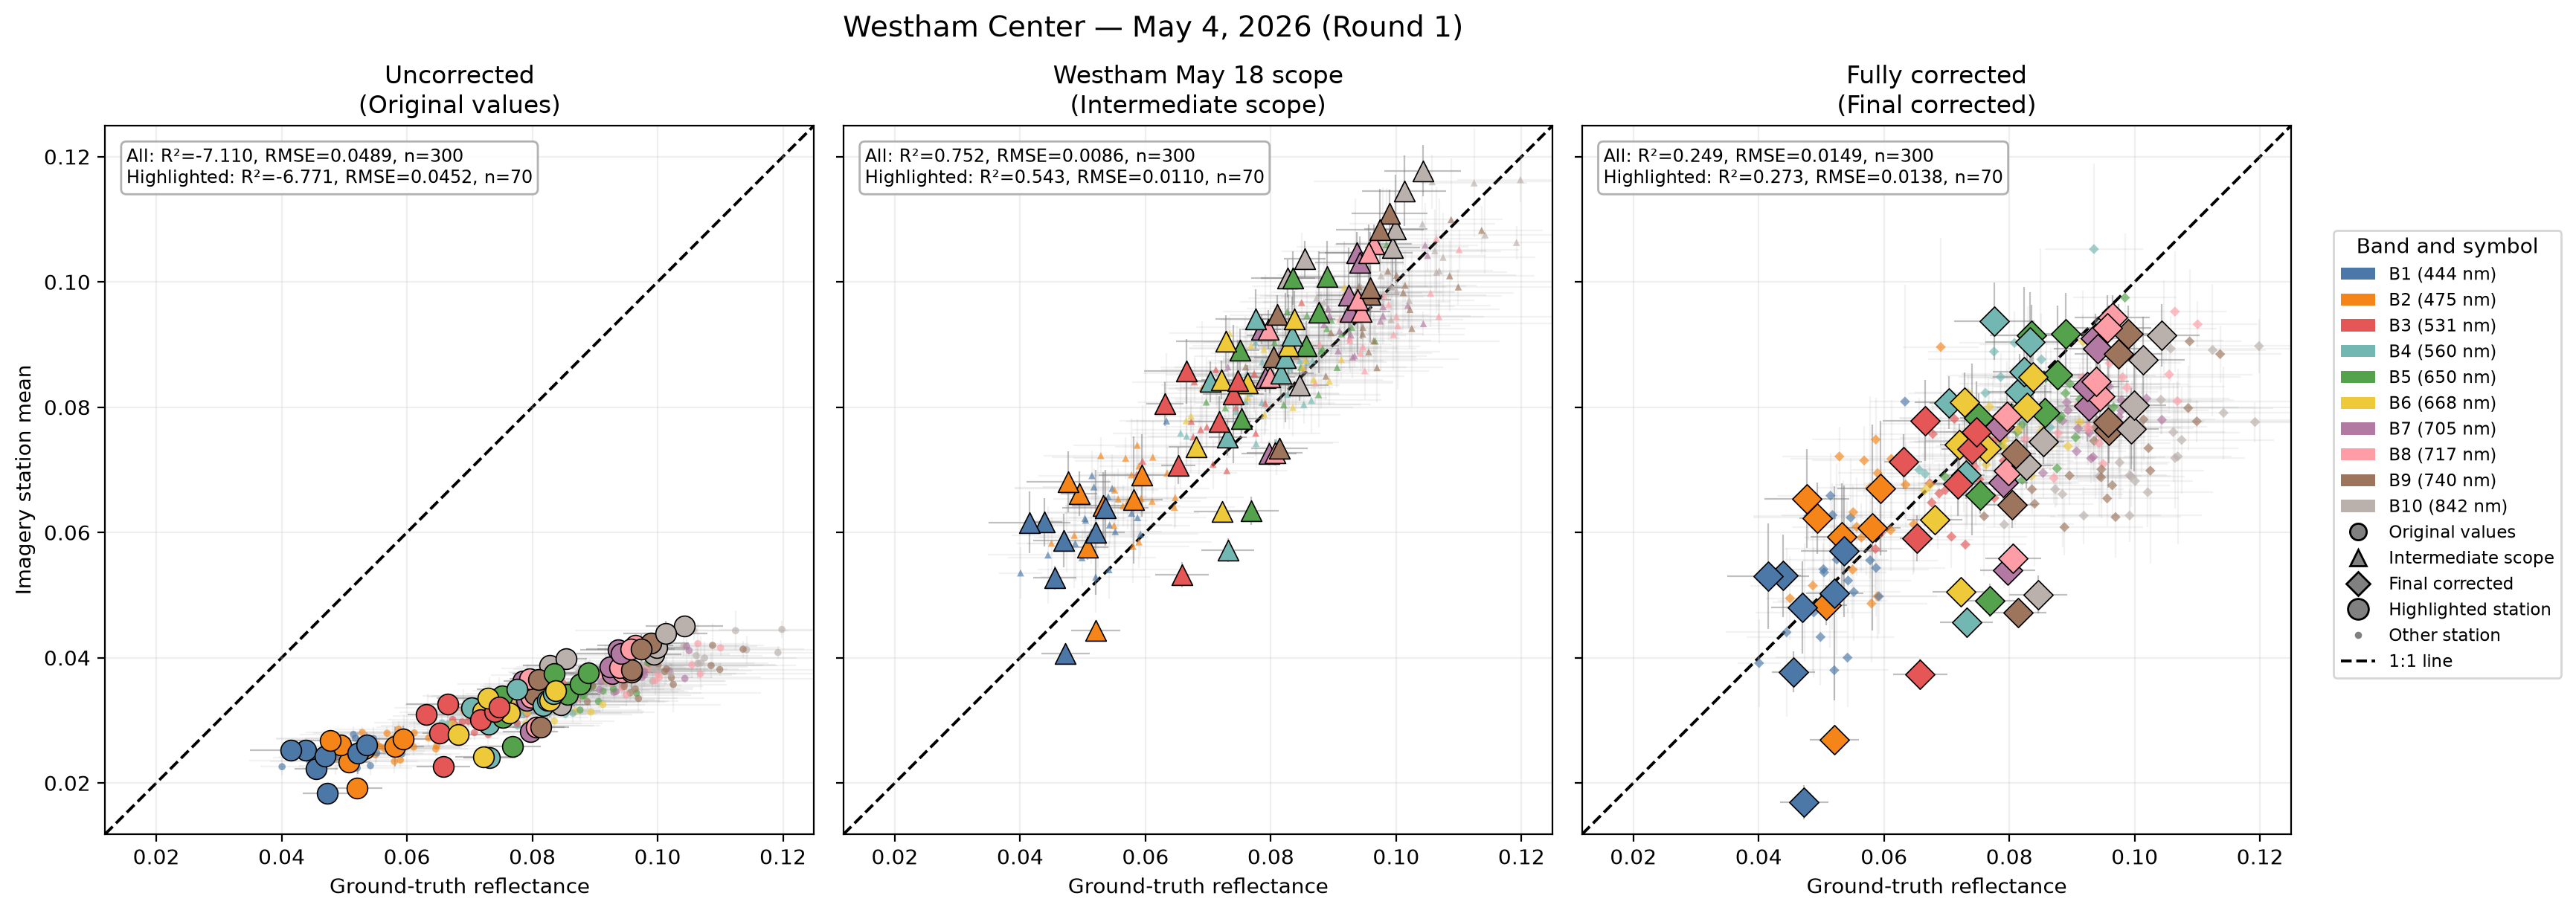

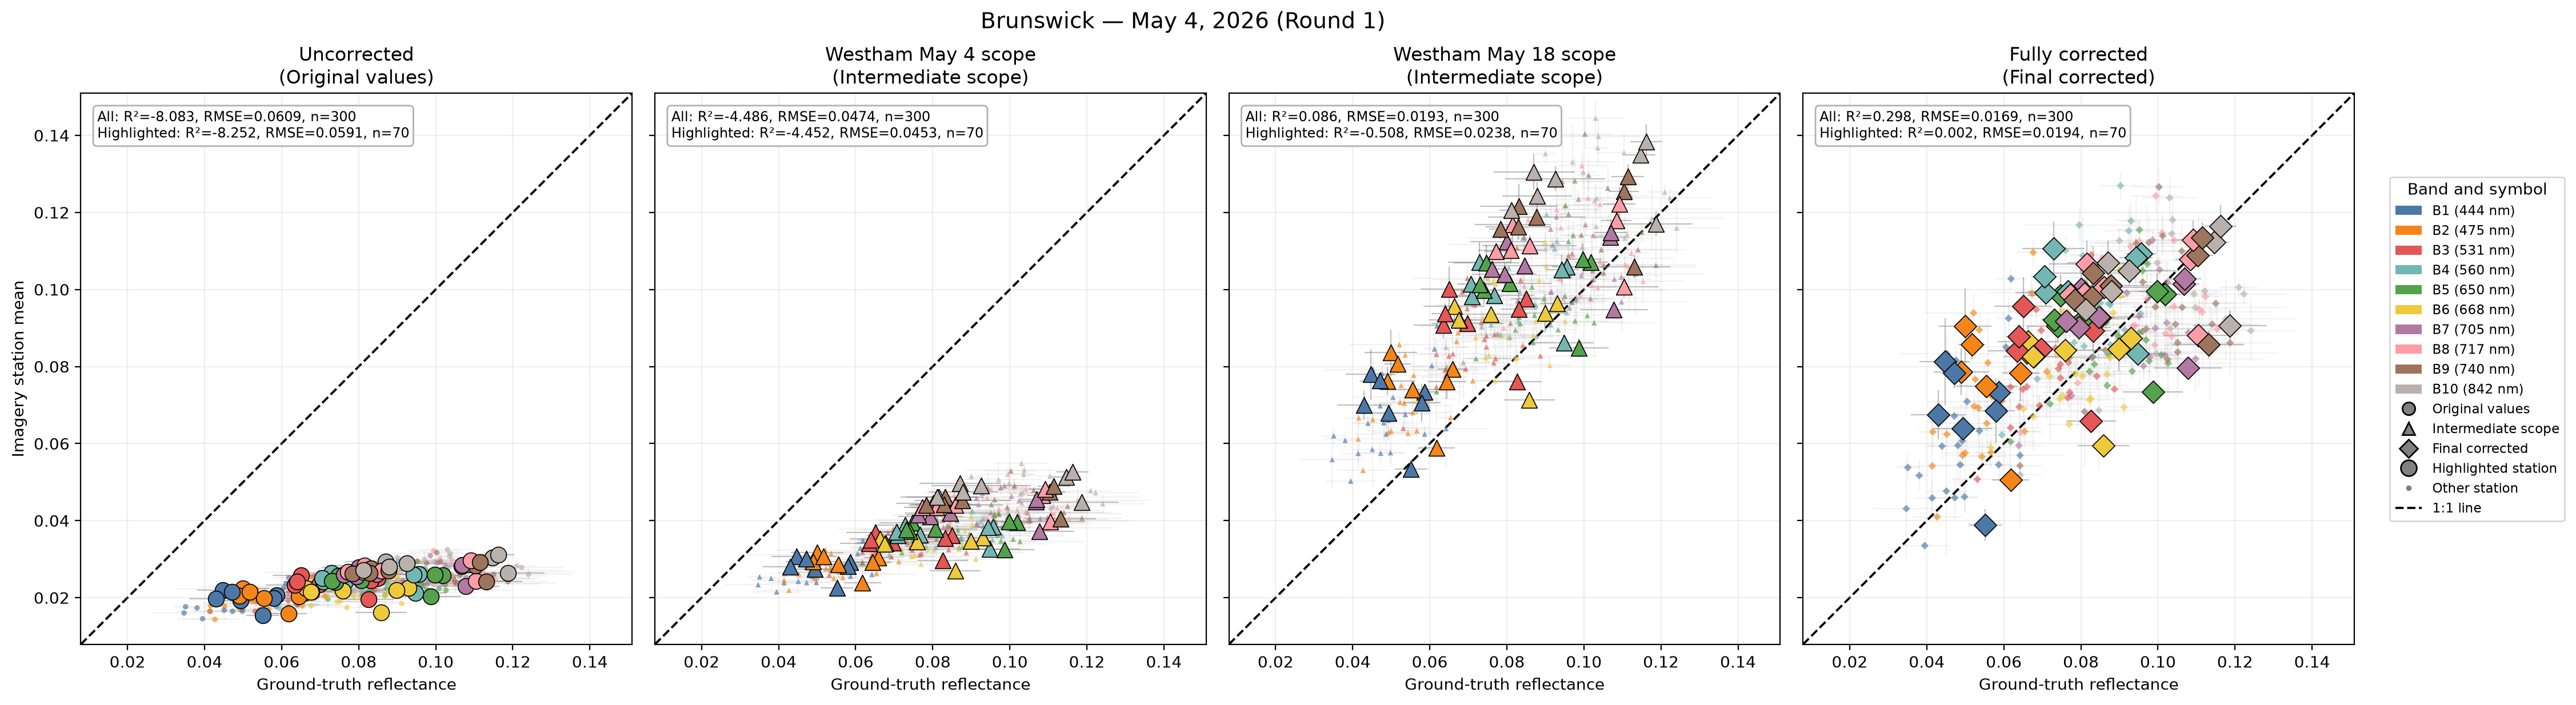

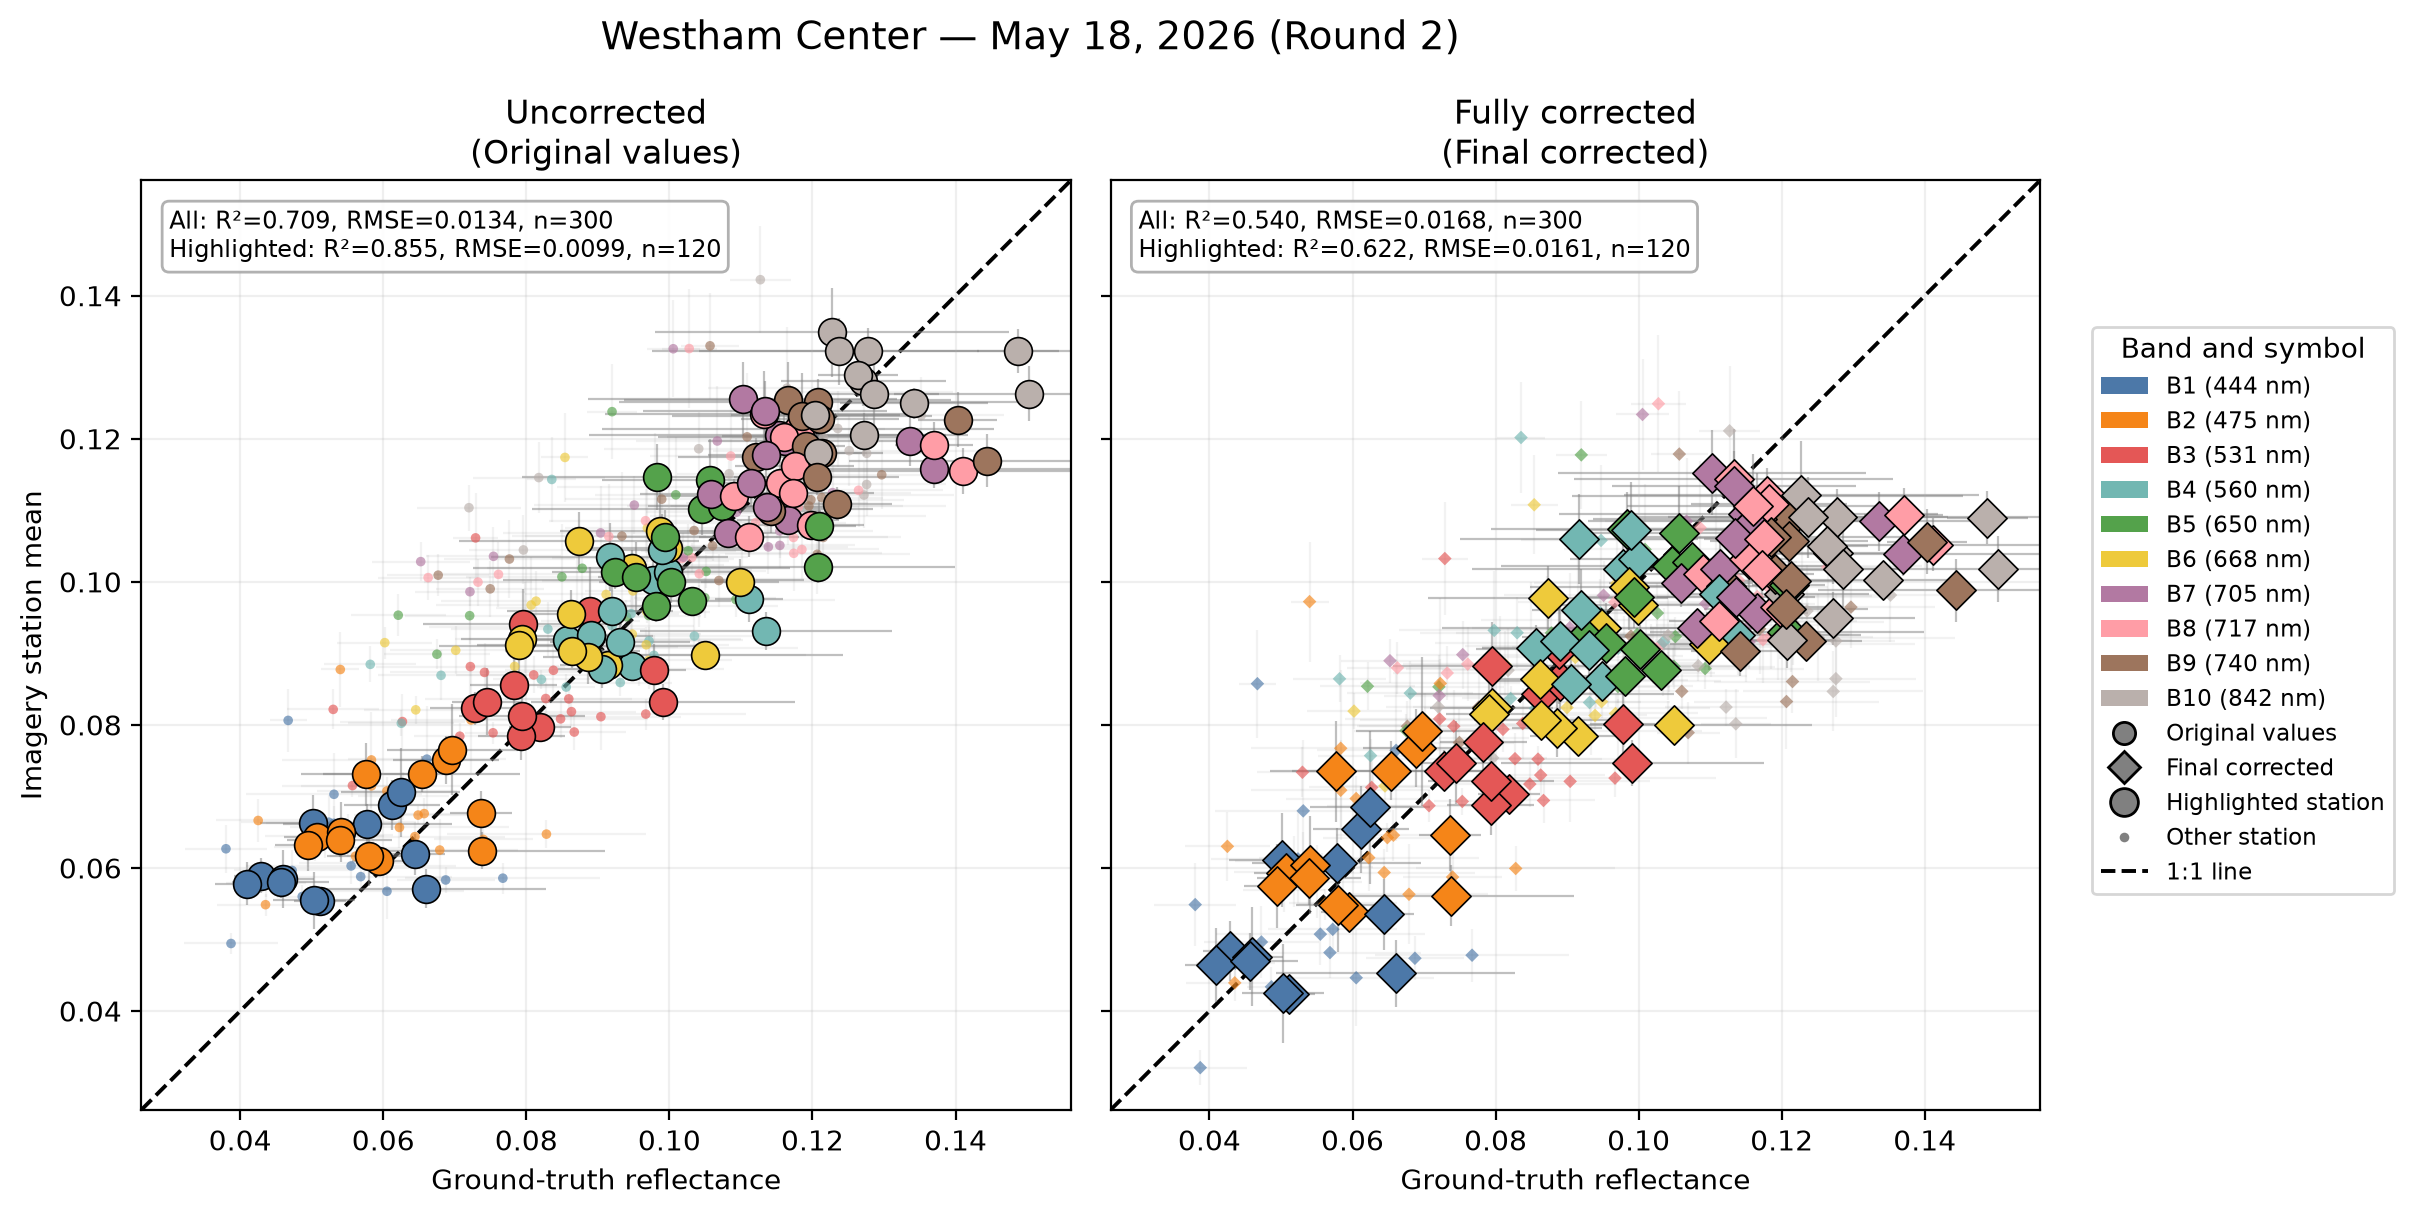

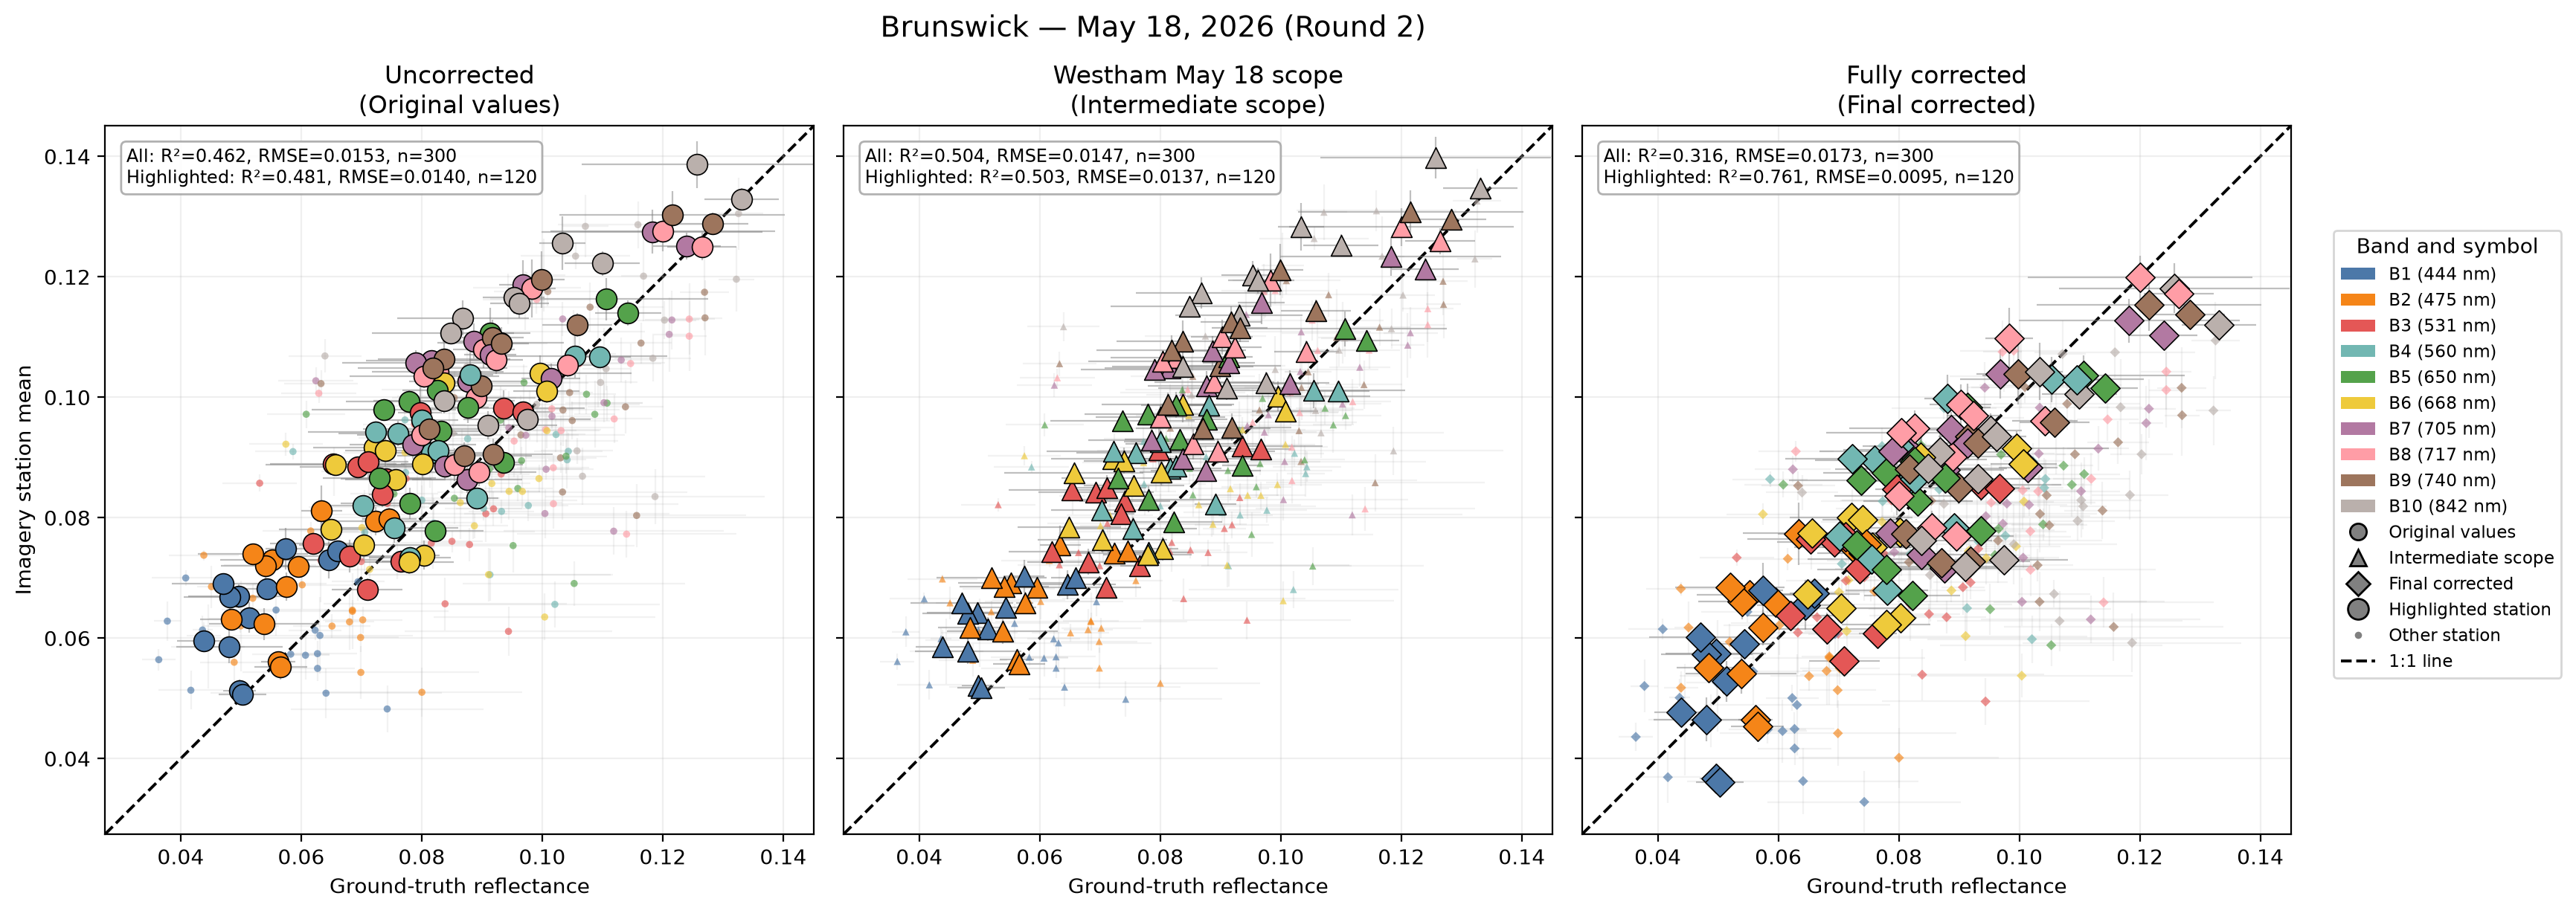

In [33]:
figure_order = [
    (1, "westham"),
    (1, "brunswick"),
    (2, "westham"),
    (2, "brunswick"),
]

round_date_labels = {
    1: "May 4, 2026",
    2: "May 18, 2026",
}

for round_number, site in figure_order:
    key = (round_number, site)
    stages = STAGE_ORDER_BY_ROUND_SITE[key]

    figure_data = imagery_vs_field.loc[
        imagery_vs_field["round"].eq(round_number)
        & imagery_vs_field["site"].eq(site)
        & imagery_vs_field["image_stage"].isin(stages)
    ].copy()

    highlighted_stations = set(
        STATIONS_TO_HIGHLIGHT.get(key, [])
    )

    number_of_panels = len(stages)

    fig, axes = plt.subplots(
        1,
        number_of_panels,
        figsize=(5.2 * number_of_panels, 5.8),
        sharex=True,
        sharey=True,
        squeeze=False,
    )
    axes = axes.ravel()

    # Use identical x/y limits for every stage within this figure.
    finite_values = np.concatenate(
        [
            figure_data["ground_truth_mean"]
            .replace([np.inf, -np.inf], np.nan)
            .dropna()
            .to_numpy(),
            figure_data["mean"]
            .replace([np.inf, -np.inf], np.nan)
            .dropna()
            .to_numpy(),
        ]
    )

    if finite_values.size:
        data_min = float(finite_values.min())
        data_max = float(finite_values.max())
        padding = 0.05 * (data_max - data_min)

        if padding == 0:
            padding = 0.01

        common_lower = data_min - padding
        common_upper = data_max + padding
    else:
        common_lower = 0
        common_upper = 1

    for ax, image_stage in zip(axes, stages):
        stage_data = figure_data.loc[
            figure_data["image_stage"].eq(image_stage)
        ].copy()

        role = stage_role(image_stage)
        marker = STAGE_ROLE_MARKERS[role]

        stage_data["is_highlighted"] = (
            stage_data["station_name"].isin(
                highlighted_stations
            )
        )

        for row in stage_data.itertuples(index=False):
            if (
                not np.isfinite(row.ground_truth_mean)
                or not np.isfinite(row.mean)
            ):
                continue

            x_error = (
                row.ground_truth_std
                if np.isfinite(row.ground_truth_std)
                else None
            )
            y_error = (
                row.std
                if np.isfinite(row.std)
                else None
            )

            ax.errorbar(
                row.ground_truth_mean,
                row.mean,
                xerr=x_error,
                yerr=y_error,
                fmt="none",
                ecolor="grey",
                elinewidth=0.8,
                capsize=0,
                alpha=(
                    0.50
                    if row.is_highlighted
                    else 0.10
                ),
                zorder=1,
            )

            ax.scatter(
                row.ground_truth_mean,
                row.mean,
                marker=marker,
                s=(
                    MARKER_SIZE_HIGHLIGHT
                    if row.is_highlighted
                    else MARKER_SIZE_DEFAULT
                ),
                color=BAND_COLORS[row.band_name],
                edgecolor=(
                    "black"
                    if row.is_highlighted
                    else "none"
                ),
                linewidth=(
                    0.6
                    if row.is_highlighted
                    else 0
                ),
                alpha=(
                    1.0
                    if row.is_highlighted
                    else 0.65
                ),
                zorder=(
                    3
                    if row.is_highlighted
                    else 2
                ),
            )

        ax.plot(
            [common_lower, common_upper],
            [common_lower, common_upper],
            "k--",
            linewidth=1.4,
            zorder=0,
        )

        ax.set_xlim(common_lower, common_upper)
        ax.set_ylim(common_lower, common_upper)
        ax.set_aspect("equal", adjustable="box")
        ax.grid(alpha=0.20)

        all_metrics = calculate_panel_metrics(stage_data)
        highlighted_metrics = calculate_panel_metrics(
            stage_data.loc[
                stage_data["is_highlighted"]
            ]
        )

        metric_lines = [
            format_panel_metric_line(
                "All",
                all_metrics,
            )
        ]

        if highlighted_metrics["n"] > 0:
            metric_lines.append(
                format_panel_metric_line(
                    "Highlighted",
                    highlighted_metrics,
                )
            )

        ax.text(
            0.03,
            0.97,
            "\n".join(metric_lines),
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=8.5,
            bbox={
                "boxstyle": "round,pad=0.3",
                "facecolor": "white",
                "edgecolor": "0.65",
                "alpha": 0.88,
            },
        )

        ax.set_title(
            f"{STAGE_LABELS[image_stage]}\n"
            f"({STAGE_ROLE_LABELS[role]})"
        )
        ax.set_xlabel("Ground-truth reflectance")

    axes[0].set_ylabel("Imagery station mean")

    band_handles_stage = [
        Patch(
            facecolor=BAND_COLORS[band_name],
            edgecolor="none",
            label=(
                f"{band_name} "
                f"({BAND_WAVELENGTHS[band_name]} nm)"
            ),
        )
        for band_name in BAND_NAMES
    ]

    role_handles = [
        Line2D(
            [0],
            [0],
            marker=STAGE_ROLE_MARKERS[role],
            linestyle="none",
            markerfacecolor="grey",
            markeredgecolor="black",
            markersize=8,
            label=STAGE_ROLE_LABELS[role],
        )
        for role in ["original", "intermediate", "final"]
        if role in {
            stage_role(stage)
            for stage in stages
        }
    ]

    size_handles_stage = [
        Line2D(
            [0],
            [0],
            marker="o",
            linestyle="none",
            markerfacecolor="grey",
            markeredgecolor="black",
            markersize=np.sqrt(
                MARKER_SIZE_HIGHLIGHT
            ),
            label="Highlighted station",
        ),
        Line2D(
            [0],
            [0],
            marker="o",
            linestyle="none",
            markerfacecolor="grey",
            markeredgecolor="none",
            markersize=np.sqrt(
                MARKER_SIZE_DEFAULT
            ),
            label="Other station",
        ),
        Line2D(
            [0],
            [0],
            linestyle="--",
            color="black",
            linewidth=1.4,
            label="1:1 line",
        ),
    ]

    fig.legend(
        handles=(
            band_handles_stage
            + role_handles
            + size_handles_stage
        ),
        bbox_to_anchor=(1.005, 0.5),
        loc="center left",
        fontsize="small",
        title="Band and symbol",
    )

    fig.suptitle(
        (
            f"{SITE_CONFIG[site]['label']} — "
            f"{round_date_labels[round_number]} "
            f"(Round {round_number})"
        ),
        fontsize=14,
        y=1.01,
    )

    plt.tight_layout()
    plt.show()

## 22. Metrics for all and highlighted stations

In [34]:
def calculate_comparison_metrics(group):
    valid = group[
        ["ground_truth_mean", "mean"]
    ].dropna()

    if len(valid) < 2:
        return pd.Series(
            {
                "n": len(valid),
                "r2": np.nan,
                "mae": np.nan,
                "rmse": np.nan,
                "mean_bias": np.nan,
            }
        )

    observed = valid["ground_truth_mean"].to_numpy()
    predicted = valid["mean"].to_numpy()
    residual = predicted - observed

    return pd.Series(
        {
            "n": len(valid),
            "r2": r2_score(observed, predicted),
            "mae": np.mean(np.abs(residual)),
            "rmse": np.sqrt(np.mean(residual ** 2)),
            "mean_bias": np.mean(residual),
        }
    )


comparison_data = imagery_vs_field.copy()

comparison_data["is_highlighted"] = [
    station_name in set(
        STATIONS_TO_HIGHLIGHT[(round_number, site)]
    )
    for round_number, site, station_name in zip(
        comparison_data["round"],
        comparison_data["site"],
        comparison_data["station_name"],
    )
]

metrics_all_input = comparison_data.assign(
    station_subset="All stations"
)

metrics_highlighted_input = (
    comparison_data.loc[comparison_data["is_highlighted"]]
    .copy()
    .assign(station_subset="Highlighted stations")
)

metrics_input = pd.concat(
    [metrics_all_input, metrics_highlighted_input],
    ignore_index=True,
)

comparison_metrics_by_subset = (
    metrics_input
    .groupby(
        [
            "round",
            "site",
            "image_stage",
            "station_subset",
        ],
        observed=True,
    )
    .apply(calculate_comparison_metrics)
    .reset_index()
    .sort_values(
        [
            "round",
            "site",
            "image_stage",
            "station_subset",
        ]
    )
)

display(comparison_metrics_by_subset)

r2_summary = comparison_metrics_by_subset.pivot_table(
    index=["round", "site", "image_stage"],
    columns="station_subset",
    values="r2",
)

display(r2_summary)

,round,site,image_stage,station_subset,n,r2,mae,rmse,mean_bias
0,1,brunswick,fully_corrected,All stations,300.0,0.298205,0.013990,0.016938,0.004828
1,1,brunswick,fully_corrected,Highlighted stations,70.0,0.002283,0.016799,0.019392,0.009896
2,1,brunswick,uncorrected,All stations,300.0,-8.082976,0.058311,0.060936,-0.058311
3,1,brunswick,uncorrected,Highlighted stations,70.0,-8.252241,0.056415,0.059052,-0.056415
4,1,brunswick,westham_may18_scope,All stations,300.0,0.086369,0.016279,0.019326,0.014671
5,1,brunswick,westham_may18_scope,Highlighted stations,70.0,-0.508200,0.021180,0.023842,0.018901
6,1,brunswick,westham_may4_scope,All stations,300.0,-4.486372,0.044909,0.047359,-0.044909
7,1,brunswick,westham_may4_scope,Highlighted stations,70.0,-4.451883,0.042696,0.045330,-0.042696
8,1,westham,fully_corrected,All stations,300.0,0.249013,0.011544,0.014888,-0.008261
9,1,westham,fully_corrected,Highlighted stations,70.0,0.273357,0.010622,0.013825,-0.006175


station_subset                       All stations  Highlighted stations
round site      image_stage                                            
1     brunswick fully_corrected          0.298205              0.002283
                uncorrected             -8.082976             -8.252241
                westham_may18_scope      0.086369             -0.508200
                westham_may4_scope      -4.486372             -4.451883
      westham   fully_corrected          0.249013              0.273357
                uncorrected             -7.109841             -6.771457
                westham_may18_scope      0.752035              0.542888
2     brunswick fully_corrected          0.316318              0.760739
                uncorrected              0.461992              0.480788
                westham_may18_scope      0.503858              0.502582
      westham   fully_corrected          0.539624              0.621824
                uncorrected              0.708906              0.855016

## 23. Metrics by spectral band

In [35]:
comparison_metrics_by_band = (
    metrics_input
    .groupby(
        [
            "round",
            "site",
            "image_stage",
            "station_subset",
            "band_name",
            "wavelength_nm",
        ],
        observed=True,
    )
    .apply(calculate_comparison_metrics)
    .reset_index()
    .sort_values(
        [
            "round",
            "site",
            "station_subset",
            "wavelength_nm",
            "image_stage",
        ]
    )
)

display(comparison_metrics_by_band)

rmse_by_band = comparison_metrics_by_band.pivot_table(
    index=[
        "round",
        "site",
        "station_subset",
        "band_name",
        "wavelength_nm",
    ],
    columns="image_stage",
    values="rmse",
)

display(rmse_by_band)

,round,site,image_stage,station_subset,band_name,wavelength_nm,n,r2,mae,rmse,mean_bias
0,1,brunswick,fully_corrected,All stations,B1,444,30.0,-5.662697,0.016527,0.019976,0.013951
20,1,brunswick,uncorrected,All stations,B1,444,30.0,-14.938938,0.030110,0.030896,-0.030110
40,1,brunswick,westham_may18_scope,All stations,B1,444,30.0,-5.918059,0.018425,0.020355,0.018285
60,1,brunswick,westham_may4_scope,All stations,B1,444,30.0,-7.854922,0.021987,0.023029,-0.021987
2,1,brunswick,fully_corrected,All stations,B2,475,30.0,-7.025261,0.018869,0.022361,0.017856
...,...,...,...,...,...,...,...,...,...,...,...
238,2,westham,uncorrected,Highlighted stations,B8,717,12.0,-0.272352,0.007576,0.010465,-0.003764
219,2,westham,fully_corrected,Highlighted stations,B9,740,12.0,-5.686359,0.021653,0.024124,-0.021653
239,2,westham,uncorrected,Highlighted stations,B9,740,12.0,-0.371250,0.007991,0.010925,-0.003873
211,2,westham,fully_corrected,Highlighted stations,B10,842,12.0,-8.070463,0.026733,0.028634,-0.026733


image_stage                                                   fully_corrected  \
round site      station_subset       band_name wavelength_nm                    
1     brunswick All stations         B1        444                   0.019976   
                                     B10       842                   0.016924   
                                     B2        475                   0.022361   
                                     B3        531                   0.015206   
                                     B4        560                   0.020298   
...                                                                       ...   
2     westham   Highlighted stations B5        650                   0.012282   
                                     B6        668                   0.010733   
                                     B7        705                   0.015639   
                                     B8        717                   0.017296   
                                     B9        740                   0.024124   

image_stage                                                   uncorrected  \
round site      station_subset       band_name wavelength_nm                
1     brunswick All stations         B1        444               0.030896   
                                     B10       842               0.076430   
                                     B2        475               0.036596   
                                     B3        531               0.050526   
                                     B4        560               0.059215   
...                                                                   ...   
2     westham   Highlighted stations B5        650               0.009543   
                                     B6        668               0.010112   
                                     B7        705               0.009894   
                                     B8        717               0.010465   
                                     B9        740               0.010925   

image_stage                                                   westham_may18_scope  \
round site      station_subset       band_name wavelength_nm                        
1     brunswick All stations         B1        444                       0.020355   
                                     B10       842                       0.025020   
                                     B2        475                       0.019630   
                                     B3        531                       0.019305   
                                     B4        560                       0.018422   
...                                                                           ...   
2     westham   Highlighted stations B5        650                            NaN   
                                     B6        668                            NaN   
                                     B7        705                            NaN   
                                     B8        717                            NaN   
                                     B9        740                            NaN   

image_stage                                                   westham_may4_scope  
round site      station_subset       band_name wavelength_nm                      
1     brunswick All stations         B1        444                      0.023029  
                                     B10       842                      0.057424  
                                     B2        475                      0.028050  
                                     B3        531                      0.040003  
                                     B4        560                      0.047459  
...                                                                          ...  
2     westham   Highlighted stations B5        650                           NaN  
                                     B6        668                           NaN  
        

## 24. Optional field spectral indices by round

In [36]:
field_indices = pd.DataFrame(index=field_r.index)
field_r_matrix = field_r.T

field_indices["NDVI740"] = compute_ndvi740(field_r_matrix)
field_indices["NDVI842"] = compute_ndvi842(field_r_matrix)
field_indices["NDCI3"] = compute_ndci3(field_r_matrix)
field_indices["NDCI2"] = compute_ndci2(field_r_matrix)

field_index_summary = (
    field_indices
    .groupby(["station_id", "round", "sample_type"])
    .agg(["mean", "std"])
)

display(field_index_summary.head())

NDVI740             NDVI842            \
                                  mean       std      mean       std   
station_id round sample_type                                           
B1         1     R            0.120326  0.012212  0.154022  0.011689   
           2     R            0.122321  0.025191  0.143667  0.027458   
B10        1     R            0.179997  0.028614  0.201283  0.028692   
           2     R            0.147256  0.027480  0.166821  0.026711   
B11        1     R            0.131063  0.015741  0.161518  0.016238   

                                 NDCI3               NDCI2            
                                  mean       std      mean       std  
station_id round sample_type                                          
B1         1     R            0.066917  0.008456  0.077830  0.010524  
           2     R            0.070355  0.014316  0.090313  0.019515  
B10        1     R            0.107470  0.018827  0.135112  0.025909  
           2     R            0.088908  0.018788  0.114427  0.025930  
B11        1     R            0.071969  0.009892  0.082590  0.013763

## 25. Optional output export

In [37]:
if SAVE_OUTPUTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    spectra_pixels_wide.to_parquet(
        OUTPUT_DIR
        / "westham_brunswick_rounds1_2_pixel_spectra_wide.parquet",
        index=False,
    )

    spectra_pixels_long.to_parquet(
        OUTPUT_DIR
        / "westham_brunswick_rounds1_2_pixel_spectra_long.parquet",
        index=False,
    )

    station_spectral_summary.to_csv(
        OUTPUT_DIR
        / "westham_brunswick_rounds1_2_station_summary.csv",
        index=False,
    )

    imagery_vs_field.to_csv(
        OUTPUT_DIR
        / "westham_brunswick_rounds1_2_R_imagery_vs_field.csv",
        index=False,
    )

    comparison_metrics_by_subset.to_csv(
        OUTPUT_DIR
        / "westham_brunswick_rounds1_2_R_metrics.csv",
        index=False,
    )

    comparison_metrics_by_band.to_csv(
        OUTPUT_DIR
        / "westham_brunswick_rounds1_2_R_metrics_by_band.csv",
        index=False,
    )

    calibration_overview.to_csv(
        OUTPUT_DIR / "all_calibration_coefficients.csv",
        index=False,
    )

    for (round_number, site), selected in selected_stations.items():
        selected.to_file(
            OUTPUT_DIR
            / f"{site}_round{round_number}_2x2_selected_stations.geojson",
            driver="GeoJSON",
        )

    if not westham_r2_calibration_residual_summary.empty:
        westham_r2_calibration_residual_summary.to_csv(
            OUTPUT_DIR
            / "westham_round2_calibration_residual_summary.csv",
            index=False,
        )

    print("Outputs written to:", OUTPUT_DIR)
else:
    print("SAVE_OUTPUTS is False; no files were written.")

Outputs written to: /home/coder/jchampion/Biofilm_LEG13553/confidential-leg13553-biofilm/data/processed/spectra/imagery_comparison_rounds1_2


## Notes and assumptions

- The Round 1 Brunswick chain is:
  1. Brunswick May 4 → Westham May 4 scope;
  2. Westham May 4 → Westham May 18 scope;
  3. Westham May 18 final correction.
- The Round 1 Westham chain starts at step 2.
- The Round 2 Brunswick chain starts at the Westham May 18 scope conversion.
- The existing corrected Westham May 18 raster is used as the Round 2 Westham final stage.
- Source band 5/PAN is excluded. PAN coefficients are retained only in the full 11-band coefficient tables.
- Every sequential calibration chain is checked against its mathematically equivalent combined transform.
- Round 1 highlighted stations are W24–W30 and B24–B30.
- Round 2 highlighted station lists are retained from the previous notebook.
- Sample type `R` applies to the field spectra, not the polygon attributes.
- Spectral lines are explicitly sorted by wavelength before plotting.
- The imagery is treated as EPSG:6339 without raster reprojection or resampling.